<a href="https://colab.research.google.com/github/MostaryKhatun/Conference_Dengue_paper_analysis/blob/main/Conference_Dengue_lebeled_Datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Common_gene

In [ ]:
import pandas as pd
import os

# =========================
# FUNCTION (MUST RUN FIRST)
# =========================
def get_gene_set(path):
    df = pd.read_csv(path)

    # clean column names
    df.columns = df.columns.str.strip()

    # get all columns except target
    genes = (
        pd.Index(df.columns)
        .str.upper()
        .str.strip()
    )

    # remove Sample and target columns if present
    genes = genes.difference(["SAMPLE", "TARGET"])

    return set(genes)


# =========================
# COMMON GENE PIPELINE
# =========================
base_path = "/content/drive/MyDrive/Dengue_Conference_paper/Datasets"

datasets = [
    #"GSE25001_matrix_Transpose_labeled.csv",
    "GSE28991_matrix_Transpose_labeled.csv",
    "GSE43777_matrix_Transpose_labeled.csv",
    "GSE58278_matrix_Transpose_labeled.csv"
]

gene_sets = []

for ds in datasets:
    path = os.path.join(base_path, ds)

    genes = get_gene_set(path)

    print(ds, "genes:", len(genes))
    gene_sets.append(genes)

# =========================
# FIND COMMON GENES
# =========================
common_genes = set.intersection(*gene_sets)

print("\n✅ FINAL COMMON GENES:", len(common_genes))

# =========================
# SAVE COMMON GENES
# =========================
common_genes_df = pd.DataFrame(
    sorted(common_genes),
    columns=["Gene.symbol"]
)

output_file = os.path.join(base_path, "Common_Genes.csv")
common_genes_df.to_csv(output_file, index=False)

print("✅ Common genes saved to:", output_file)

GSE28991_matrix_Transpose_labeled.csv genes: 16383
GSE43777_matrix_Transpose_labeled.csv genes: 16382
GSE58278_matrix_Transpose_labeled.csv genes: 11621

✅ FINAL COMMON GENES: 3747
✅ Common genes saved to: /content/drive/MyDrive/Dengue_Conference_paper/Datasets/Common_Genes.csv


Datasets loaded:
GSE28991 16383
GSE43777 16382
GSE58278 11621


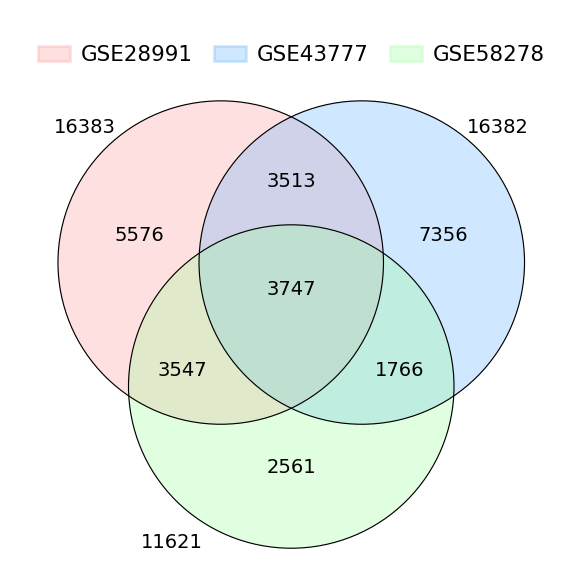

In [ ]:
# ==========================================
# Install package (run once)
# ==========================================
!pip install -q venny4py

# ==========================================
# Import library
# ==========================================
from venny4py.venny4py import *

# ==========================================
# Create full dictionary
# ==========================================
gene_dict = {
    ds.replace("_matrix_Transpose_labeled.csv", ""): genes
    for ds, genes in zip(datasets, gene_sets)
}

# ==========================================
# Choose ANY 4 datasets
# ==========================================
# selected_datasets = [
#     "GSE16463",
#     "GSE18090",
#     "GSE51808",
#     "GSE84331"
# ]
selected_datasets = [
    #"GSE25001",
    "GSE28991",
    "GSE43777",
    "GSE58278"
]

# Create dictionary for only these 4 datasets
selected_gene_dict = {
    ds: gene_dict[ds]
    for ds in selected_datasets
}

# Check loaded datasets
print("Datasets loaded:")
for ds, genes in selected_gene_dict.items():
    print(ds, len(genes))

# ==========================================
# Draw Venn Diagram
# ==========================================
venny4py(
    sets=selected_gene_dict,
    colors=[
        "#FF9999",  # GSE16463
        "#66B3FF",  # GSE18090
        "#99FF99",  # GSE51808
        "#FFD700"   # GSE84331
    ]
)

#

#ComBat Batch Effect Correction Code (Train/Test setup)


In [ ]:
!pip install pandas numpy scanpy anndata

In [ ]:
# ==========================================
# Step 2: Import
# ==========================================
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad

# ==========================================
# Step 3: Load datasets
# ==========================================
base_path = "/content/drive/MyDrive/Dengue_Conference_paper/Datasets"

train_files = [
    "GSE28991_matrix_Transpose_labeled.csv",
    "GSE43777_matrix_Transpose_labeled.csv",
    "GSE58278_matrix_Transpose_labeled.csv"
]

# ==========================================
# Step 4: Load + merge datasets
# ==========================================
dfs = []

for file in train_files:
    df = pd.read_csv(f"{base_path}/{file}")
    df.columns = df.columns.str.strip()

    df["Batch"] = file
    dfs.append(df)

combined_df = pd.concat(dfs, axis=0, ignore_index=True)

print("Combined shape:", combined_df.shape)

# ==========================================
# VERY IMPORTANT STEP
# Separate target BEFORE ComBat
# ==========================================
y = combined_df["target"].astype(int)   # preserve 0/1
batch = combined_df["Batch"]

# Expression matrix only
X = combined_df.drop(columns=["target", "Batch"])

# Numeric conversion
X = X.apply(pd.to_numeric, errors="coerce").fillna(0)

print("X shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

# ==========================================
# Step 5: ComBat correction
# ==========================================
adata = ad.AnnData(X)
adata.obs["batch"] = batch.values

sc.pp.combat(adata, key="batch")

X_corrected = pd.DataFrame(
    adata.X,
    columns=X.columns
)

print("Batch correction done!")

# ==========================================
# Step 6: Reattach target
# ==========================================
final_df = X_corrected.copy()
final_df["target"] = y.values
final_df["Batch"] = batch.values

print("Final shape:", final_df.shape)

# ==========================================
# Step 7: Save file
# ==========================================
output_path = base_path + "/combined_combat_corrected.csv"

final_df.to_csv(output_path, index=False)

print("Saved successfully!")

Combined shape: (152, 28069)
X shape: (152, 28067)
Target distribution:
target
1    114
0     38
Name: count, dtype: int64


/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_combat.py:360: RuntimeWarning: divide by zero encountered in divide
  (abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max()


Batch correction done!
Final shape: (152, 28069)
Saved successfully!


In [ ]:
print(train_corrected.columns[-5:])  # last 5 columns
print("target unique:", train_corrected["target"].unique())
print(train_corrected["target"].value_counts())

Index(['NAA30', 'CTDP1', 'ZNF112', 'target', 'Batch'], dtype='object')
target unique: [1 0]
target
1    114
0     38
Name: count, dtype: int64


In [ ]:
print("\nTrain target distribution:")
print(train_corrected["target"].value_counts())

print("\nTest target distribution:")
print(test_corrected["target"].value_counts())


Train target distribution:
target
1    114
0     38
Name: count, dtype: int64

Test target distribution:
target
1    175
0     34
Name: count, dtype: int64


#

#Before vs After ComBat (PCA Figure)

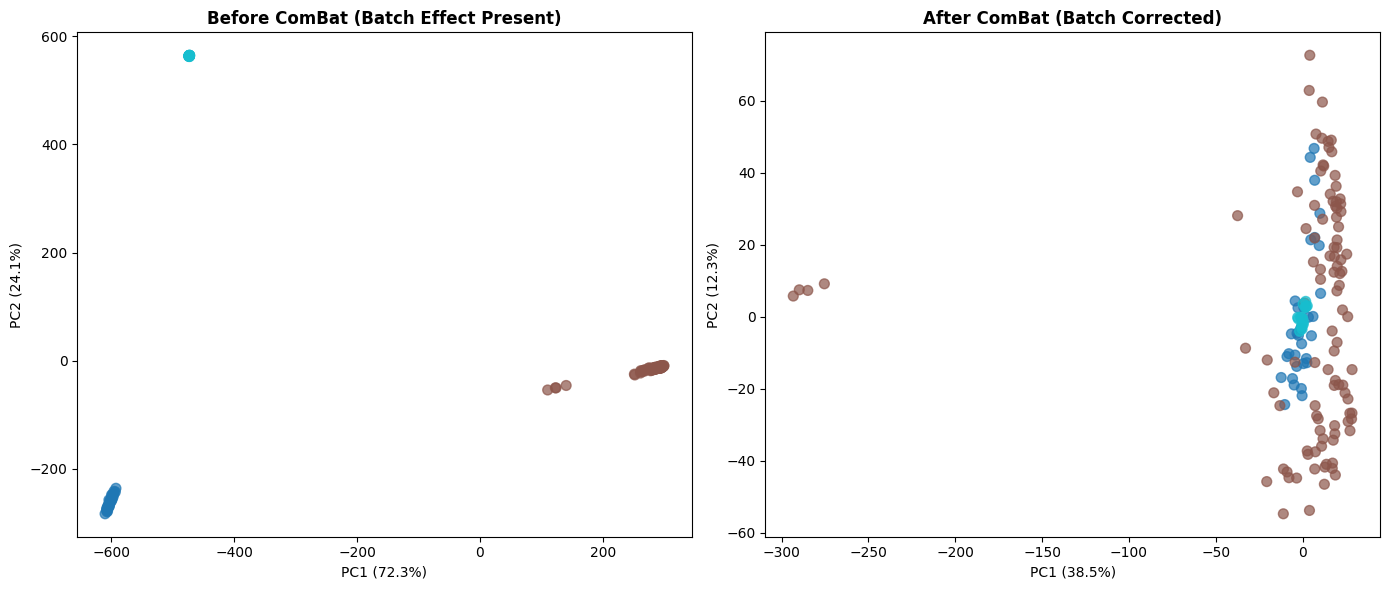

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# PCA FUNCTION
# =========================
def plot_pca(data, batch, title, ax):
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(data)

    scatter = ax.scatter(
        reduced[:, 0],
        reduced[:, 1],
        c=pd.factorize(batch)[0],
        cmap="tab10",
        alpha=0.7,
        s=50
    )

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(
        f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)"
    )
    ax.set_ylabel(
        f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
    )

# =========================
# DATA FOR PCA
# =========================

# BEFORE ComBat
expr_before = X.copy()

# AFTER ComBat
expr_after = final_df.drop(columns=["target", "Batch"])

# Batch labels
batch_labels = final_df["Batch"]

# =========================
# FIGURE SETUP
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# BEFORE ComBat
plot_pca(
    expr_before,
    batch_labels,
    "Before ComBat (Batch Effect Present)",
    axes[0]
)

# AFTER ComBat
plot_pca(
    expr_after,
    batch_labels,
    "After ComBat (Batch Corrected)",
    axes[1]
)

plt.tight_layout()
plt.show()

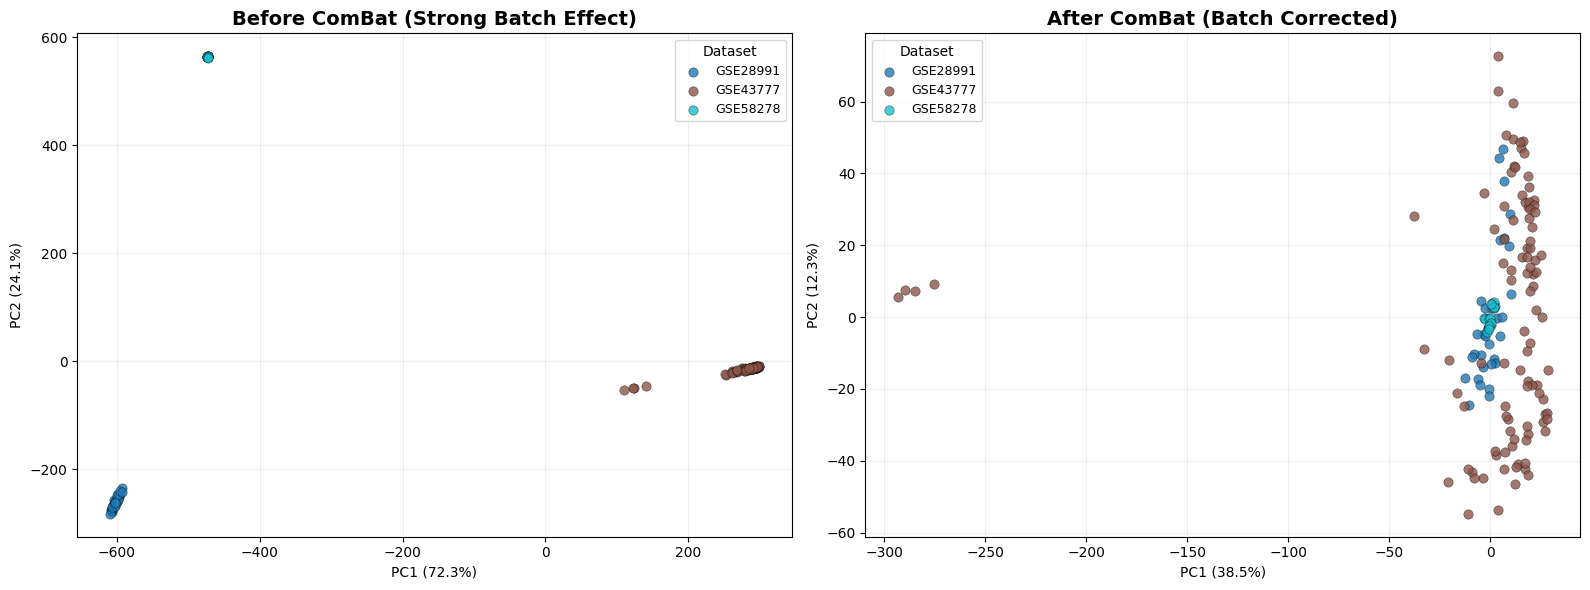

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =========================
# PCA FUNCTION (CLEAN + PAPER QUALITY)
# =========================
def plot_pca(data, batch, title, ax):

    # PCA
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(data)

    batch = pd.Series(batch).reset_index(drop=True)

    unique_batches = batch.unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_batches)))

    for color, b in zip(colors, unique_batches):
        idx = batch == b

        ax.scatter(
            reduced[idx, 0],
            reduced[idx, 1],
            color=color,
            label=b.replace("_matrix_Transpose_labeled.csv", ""),
            alpha=0.8,
            s=45,
            edgecolor="black",
            linewidth=0.3
        )

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.legend(title="Dataset", fontsize=9)
    ax.grid(alpha=0.2)


# =========================
# DATA PREPARATION
# =========================

# Before ComBat
expr_before = X.copy()

# After ComBat
expr_after = final_df.drop(columns=["target", "Batch"])

# Batch labels
batch_labels = final_df["Batch"].reset_index(drop=True)

# =========================
# PLOT
# =========================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_pca(
    expr_before,
    batch_labels,
    "Before ComBat (Strong Batch Effect)",
    axes[0]
)

plot_pca(
    expr_after,
    batch_labels,
    "After ComBat (Batch Corrected)",
    axes[1]
)

plt.tight_layout()

# =========================
# SAVE HIGH-QUALITY FIGURE
# =========================
plt.savefig(
    "/content/drive/MyDrive/Dengue_Conference_paper/PCA_Before_After_ComBat.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

#Batch Effect Quantification Score (Before vs After)

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np

# =========================
# FUNCTION: PCA embedding
# =========================
def get_embedding(data):
    pca = PCA(n_components=10, random_state=42)
    return pca.fit_transform(data)

# =========================
# DATA PREPARATION
# =========================

# BEFORE ComBat
expr_before = X.copy()

# AFTER ComBat
expr_after = final_df.drop(columns=["target", "Batch"])

# Batch labels (same for both)
batch_labels = final_df["Batch"].reset_index(drop=True)
batch_numeric = pd.factorize(batch_labels)[0]

# =========================
# EMBEDDING
# =========================

before_emb = get_embedding(expr_before)
after_emb = get_embedding(expr_after)

# =========================
# SILHOUETTE SCORE
# (lower = better mixing = less batch effect)
# =========================

before_score = silhouette_score(before_emb, batch_numeric)
after_score = silhouette_score(after_emb, batch_numeric)

# =========================
# RESULTS
# =========================
print("🔥 Batch Effect Score (Before ComBat):", round(before_score, 4))
print("✅ Batch Effect Score (After ComBat):", round(after_score, 4))

if after_score < before_score:
    print("🎯 Batch effect reduced after ComBat ✔️")
else:
    print("⚠️ Warning: Batch effect not properly corrected")

🔥 Batch Effect Score (Before ComBat): 0.9038
✅ Batch Effect Score (After ComBat): -0.1536
🎯 Batch effect reduced after ComBat ✔️


#

#Method 2 Boxplot

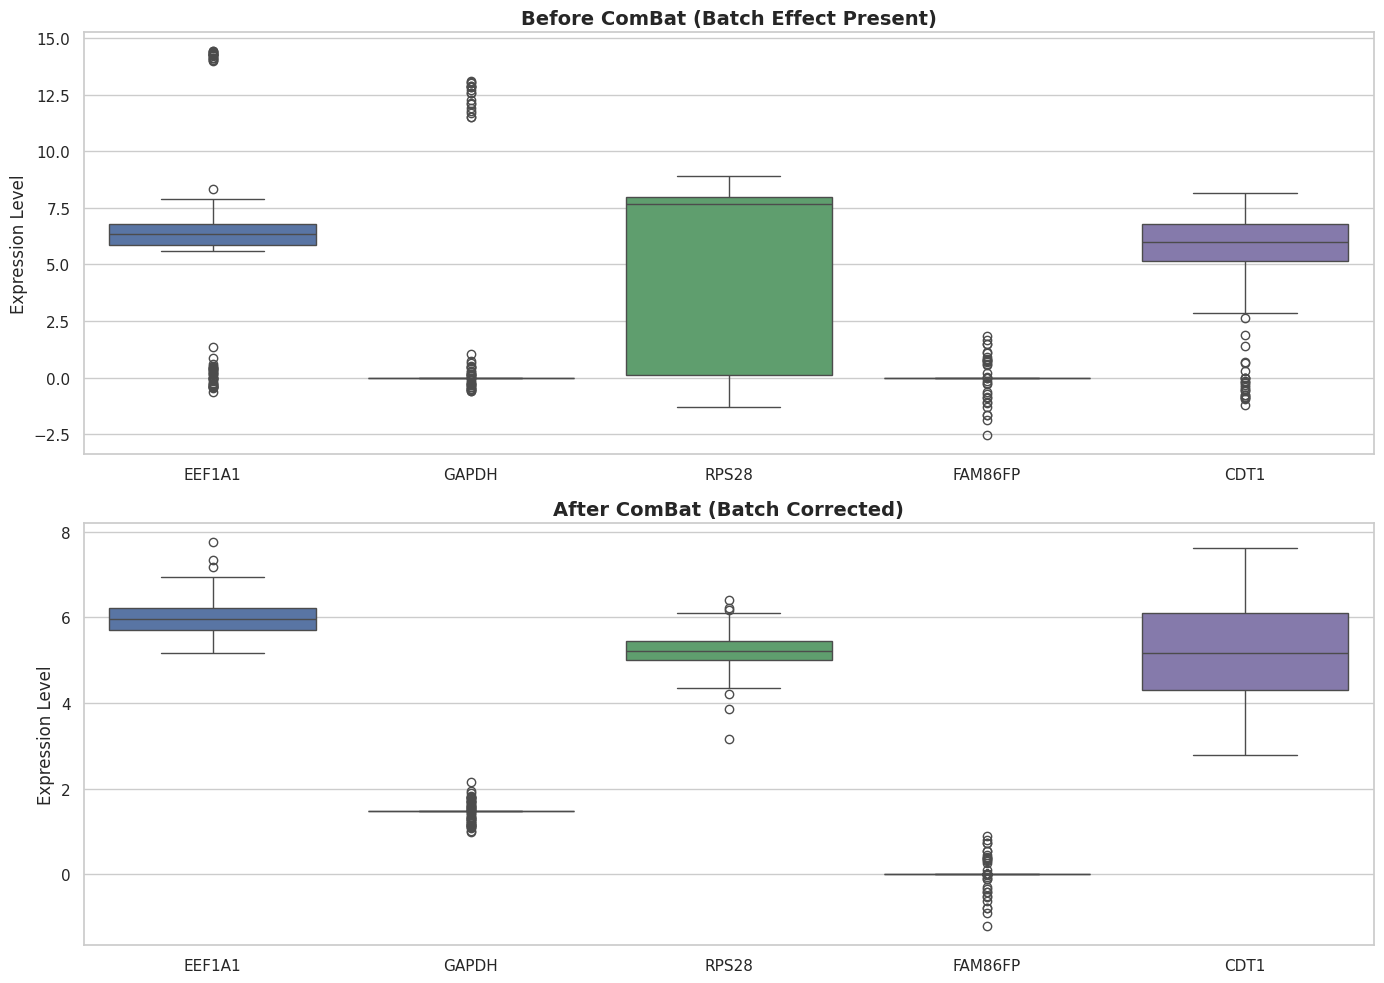

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# =========================
# DATA PREPARATION
# =========================

expr_before = X.copy()
expr_after = final_df.drop(columns=["target", "Batch"])

# same genes for fair comparison
sample_genes = expr_before.columns[:5]

# =========================
# PLOT STYLE (paper quality)
# =========================
sns.set(style="whitegrid")

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# =========================
# BEFORE COMBAT
# =========================
sns.boxplot(data=expr_before[sample_genes], ax=axes[0])
axes[0].set_title("Before ComBat (Batch Effect Present)", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Expression Level")

# =========================
# AFTER COMBAT
# =========================
sns.boxplot(data=expr_after[sample_genes], ax=axes[1])
axes[1].set_title("After ComBat (Batch Corrected)", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Expression Level")

plt.tight_layout()

# =========================
# SAVE HIGH QUALITY FIGURE
# =========================
plt.savefig(
    "/content/drive/MyDrive/Dengue_Conference_paper/Boxplot_Before_After_ComBat.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

#Method 3: Batch mixing check

In [ ]:
import pandas as pd

# =========================
# SAFETY ALIGNMENT
# =========================

corrected_df = final_df.copy()

# ensure batch alignment is correct
corrected_df["Batch"] = final_df["Batch"].values

# expression only
expr_corrected = corrected_df.drop(columns=["target", "Batch"])

# before ComBat (IMPORTANT)
expr_before = X.copy()

# =========================
# GROUP MEAN COMPARISON
# =========================

# mean expression per batch (BEFORE ComBat)
before_means = expr_before.copy()
before_means["Batch"] = final_df["Batch"].values

print("🔥 BEFORE ComBat (Batch-wise mean):")
print(before_means.groupby("Batch").mean().iloc[:5, :5])

# mean expression per batch (AFTER ComBat)
after_means = expr_corrected.copy()
after_means["Batch"] = final_df["Batch"].values

print("\n✅ AFTER ComBat (Batch-wise mean):")
print(after_means.groupby("Batch").mean().iloc[:5, :5])

🔥 BEFORE ComBat (Batch-wise mean):
                                          EEF1A1      GAPDH     RPS28  \
Batch                                                                   
GSE28991_matrix_Transpose_labeled.csv   0.067956  -0.012026  0.009058   
GSE43777_matrix_Transpose_labeled.csv   6.458284   0.000000  7.848483   
GSE58278_matrix_Transpose_labeled.csv  14.224421  12.401907  0.000000   

                                        FAM86FP      CDT1  
Batch                                                      
GSE28991_matrix_Transpose_labeled.csv -0.010319  1.021164  
GSE43777_matrix_Transpose_labeled.csv  0.000000  6.358635  
GSE58278_matrix_Transpose_labeled.csv  0.000000  6.425205  

✅ AFTER ComBat (Batch-wise mean):
                                         EEF1A1     GAPDH     RPS28   FAM86FP  \
Batch                                                                           
GSE28991_matrix_Transpose_labeled.csv  5.988380  1.466529  5.215149  0.003113   
GSE43777_matrix_Trans

In [ ]:
print("\n📊 Mean variance across batches (before vs after):")

before_var = expr_before.groupby(final_df["Batch"]).mean().var().mean()
after_var = expr_corrected.groupby(final_df["Batch"]).mean().var().mean()

print("Before ComBat variance:", before_var)
print("After ComBat variance:", after_var)

print("Reduction %:", (before_var - after_var) / before_var * 100)


📊 Mean variance across batches (before vs after):
Before ComBat variance: 14.502813366647699
After ComBat variance: 1.9881687125430225e-06
Reduction %: 99.9999862911515


#WHAT THIS GIVES YOU (FOR CONFERENCE)
📊 Visualization
PCA Before ComBat,
PCA After ComBat,
Boxplot Before,
Boxplot After
📈 Statistics
Silhouette Score (batch mixing),
Variance reduction (% batch effect removal)

🔥 Silhouette Before: 0.9038
✅ Silhouette After: -0.1536
🔥 Variance Before: 14.502813366647699
✅ Variance After: 1.9881687125430225e-06
📉 Reduction %: 99.9999862911515


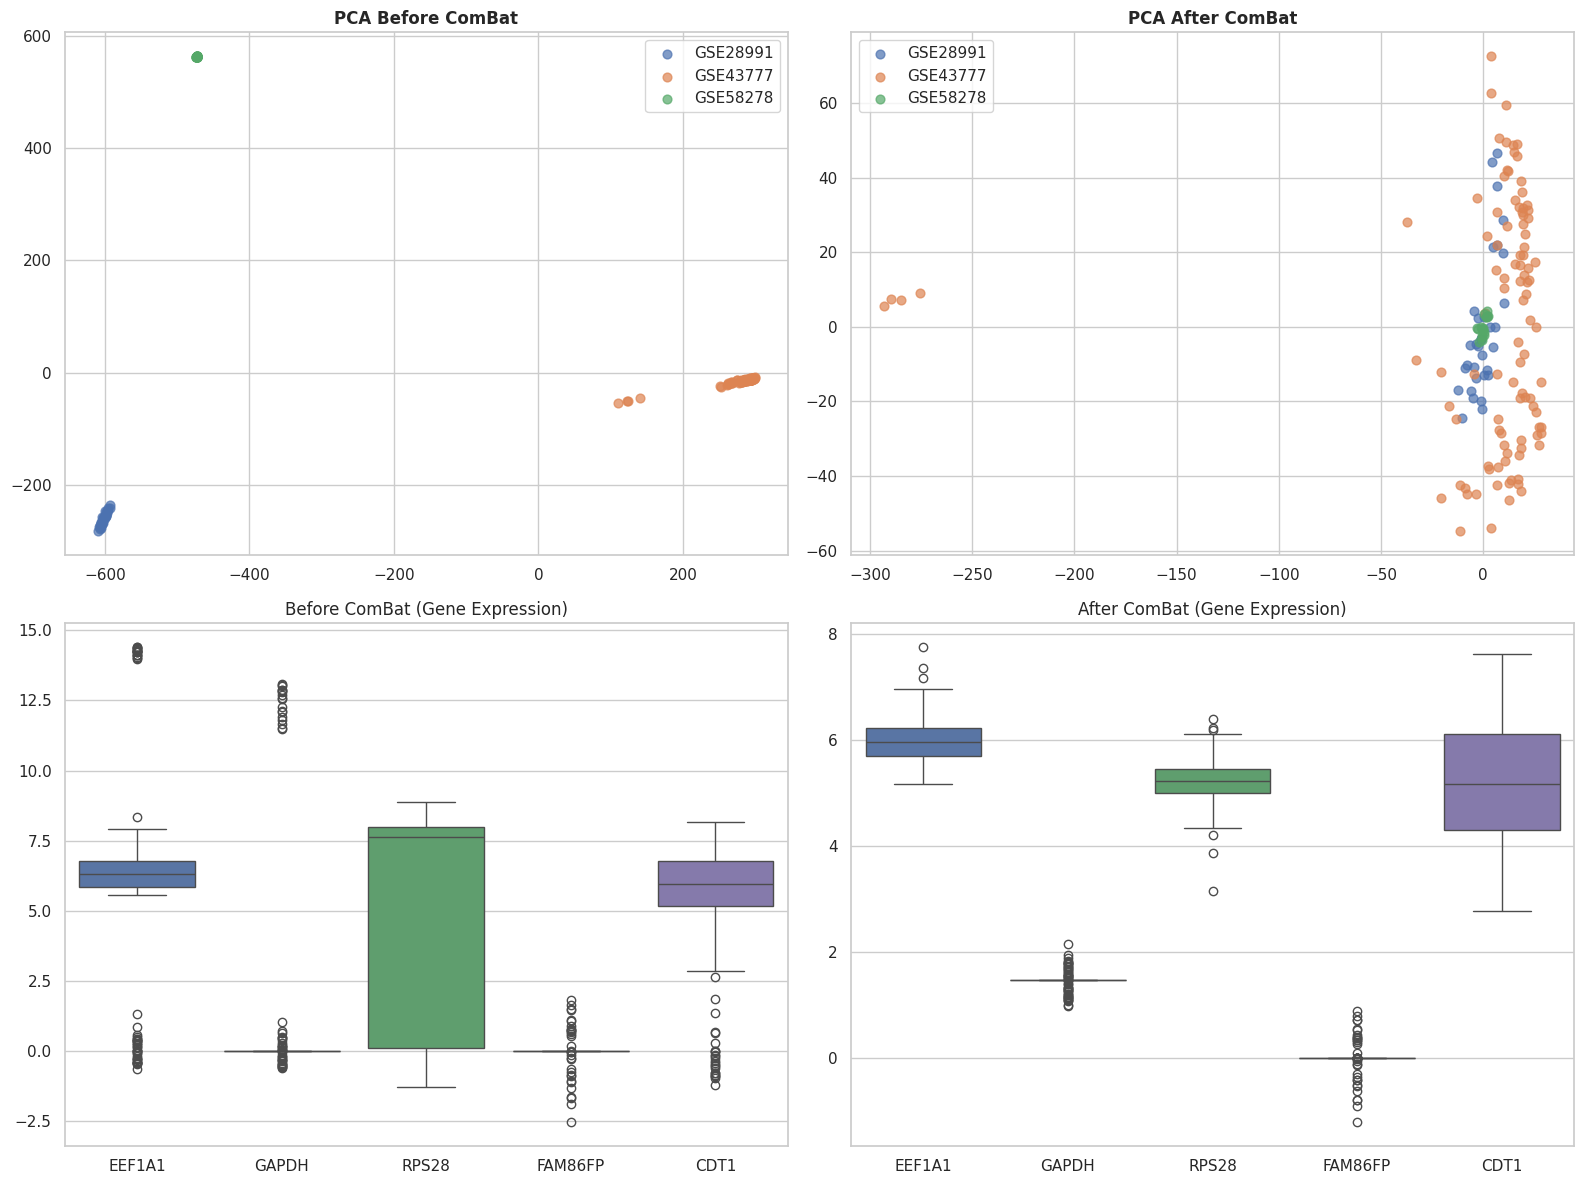

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set(style="whitegrid")

# =========================
# DATA
# =========================
expr_before = X.copy()
expr_after = final_df.drop(columns=["target", "Batch"])
batch_labels = final_df["Batch"].reset_index(drop=True)
batch_numeric = pd.factorize(batch_labels)[0]

genes = expr_before.columns[:5]  # sample genes

# =========================
# PCA FUNCTION
# =========================
def pca_plot(data, batch, ax, title):
    pca = PCA(n_components=2)
    emb = pca.fit_transform(data)

    for b in np.unique(batch):
        idx = batch == b
        ax.scatter(
            emb[idx, 0],
            emb[idx, 1],
            label=str(b).replace("_matrix_Transpose_labeled.csv", ""),
            alpha=0.7,
            s=40
        )

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend()

# =========================
# FIGURE LAYOUT
# =========================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# -------------------------
# PCA BEFORE / AFTER
# -------------------------
pca_plot(expr_before, batch_labels, axes[0,0], "PCA Before ComBat")
pca_plot(expr_after, batch_labels, axes[0,1], "PCA After ComBat")

# -------------------------
# BOXPLOT BEFORE / AFTER
# -------------------------
sns.boxplot(data=expr_before[genes], ax=axes[1,0])
axes[1,0].set_title("Before ComBat (Gene Expression)")

sns.boxplot(data=expr_after[genes], ax=axes[1,1])
axes[1,1].set_title("After ComBat (Gene Expression)")

plt.tight_layout()

# =========================
# METRICS
# =========================
before_emb = PCA(n_components=10).fit_transform(expr_before)
after_emb = PCA(n_components=10).fit_transform(expr_after)

before_sil = silhouette_score(before_emb, batch_numeric)
after_sil = silhouette_score(after_emb, batch_numeric)

before_var = expr_before.groupby(batch_labels).mean().var().mean()
after_var = expr_after.groupby(batch_labels).mean().var().mean()

print("🔥 Silhouette Before:", round(before_sil, 4))
print("✅ Silhouette After:", round(after_sil, 4))

print("🔥 Variance Before:", before_var)
print("✅ Variance After:", after_var)
print("📉 Reduction %:", ((before_var - after_var)/before_var)*100)

# =========================
# SAVE FIGURE
# =========================
plt.savefig(
    "/content/drive/MyDrive/Dengue_Conference_paper/ComBat_Validation_Panel.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

#MEAN HEATMAP (Before vs After ComBat)

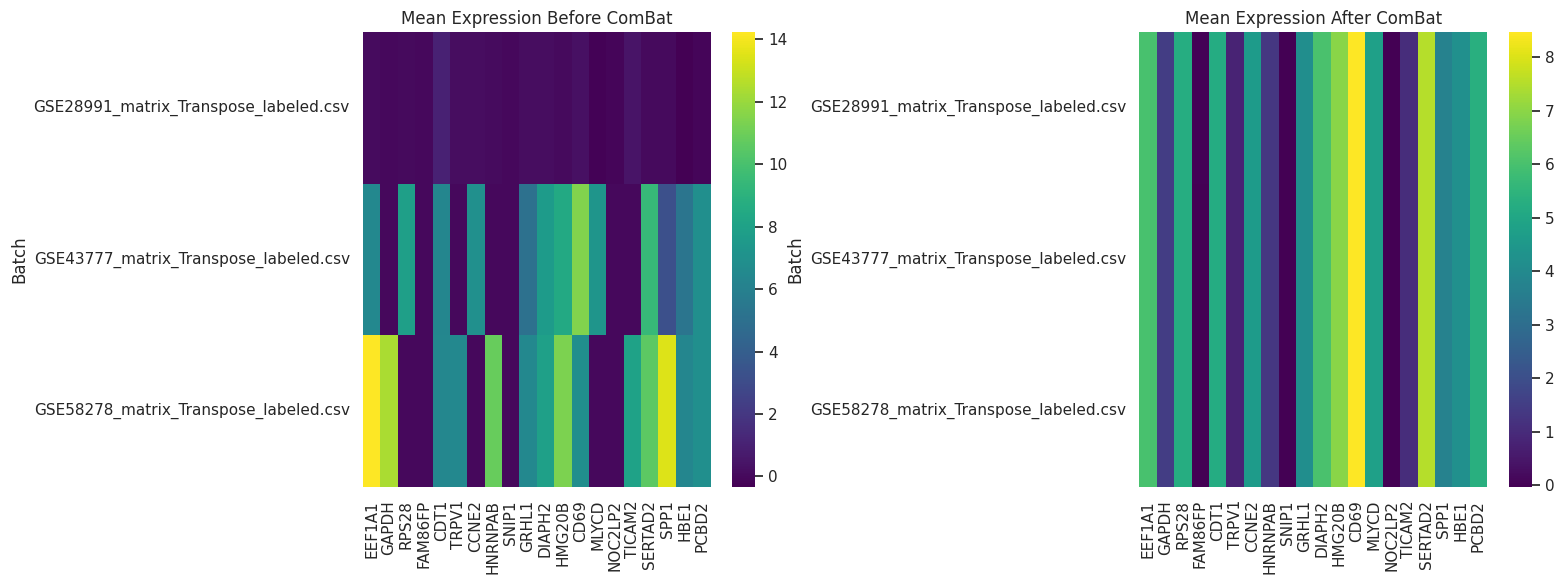

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# DATA PREP
# =========================
expr_before = X.copy()
expr_after = final_df.drop(columns=["target", "Batch"])

batch_labels = final_df["Batch"]

# mean per batch
mean_before = expr_before.copy()
mean_before["Batch"] = batch_labels.values
mean_before = mean_before.groupby("Batch").mean()

mean_after = expr_after.copy()
mean_after["Batch"] = batch_labels.values
mean_after = mean_after.groupby("Batch").mean()

# =========================
# PLOT
# =========================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(mean_before.iloc[:, :20], ax=axes[0], cmap="viridis")
axes[0].set_title("Mean Expression Before ComBat")

sns.heatmap(mean_after.iloc[:, :20], ax=axes[1], cmap="viridis")
axes[1].set_title("Mean Expression After ComBat")

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Dengue_Conference_paper/Mean_Heatmap_ComBat.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

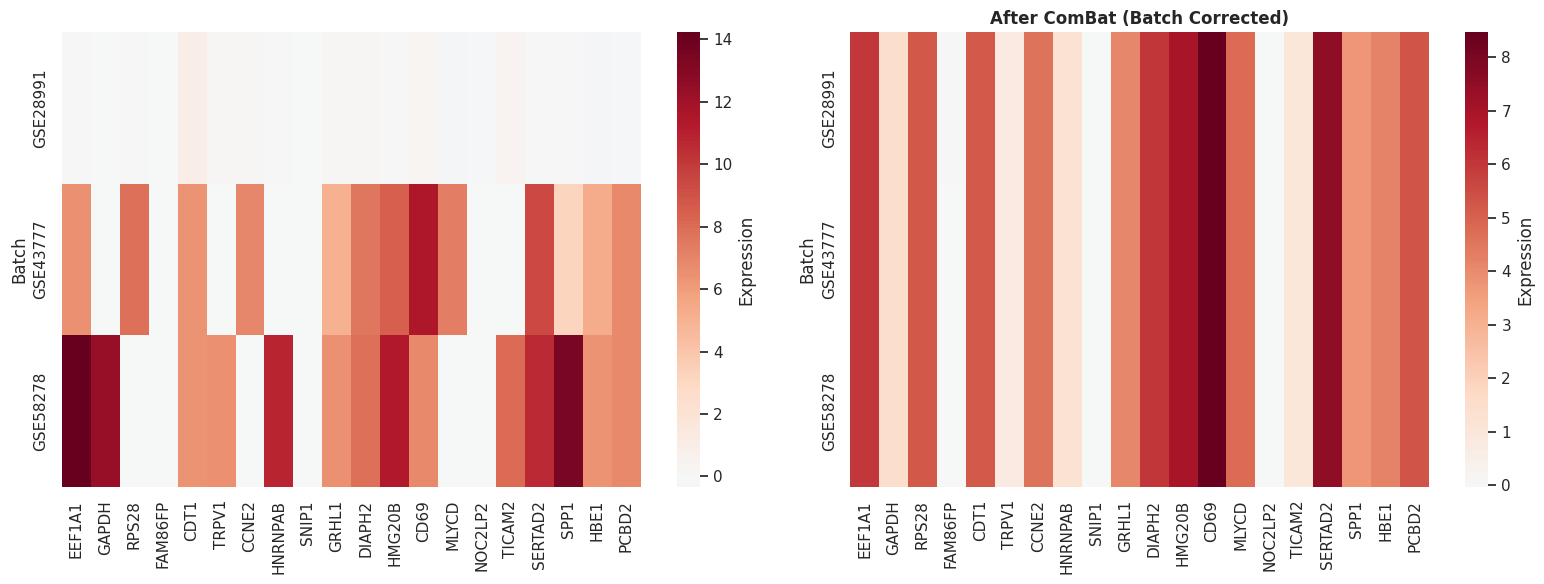

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# CLEAN BATCH NAMES
# =========================
def clean_name(x):
    return x.split("_")[0]   # keeps only GSE ID

batch_clean = final_df["Batch"].apply(clean_name)

# =========================
# DATA PREP
# =========================
expr_before = X.copy()
expr_after = final_df.drop(columns=["target", "Batch"])

# add cleaned batch
before_df = expr_before.copy()
before_df["Batch"] = batch_clean.values

after_df = expr_after.copy()
after_df["Batch"] = batch_clean.values

# mean per batch
mean_before = before_df.groupby("Batch").mean()
mean_after = after_df.groupby("Batch").mean()

# =========================
# BETTER COLOR STYLE
# =========================
sns.set(style="white")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# limit genes for visibility
n_genes = 20

sns.heatmap(
    mean_before.iloc[:, :n_genes],
    cmap="RdBu_r",   # ⭐ BEST FOR PUBLICATION
    center=0,
    ax=axes[0],
    cbar_kws={'label': 'Expression'}
)

sns.heatmap(
    mean_after.iloc[:, :n_genes],
    cmap="RdBu_r",   # ⭐ SAME COLOR FOR FAIR COMPARISON
    center=0,
    ax=axes[1],
    cbar_kws={'label': 'Expression'}
)
axes[1].set_title("After ComBat (Batch Corrected)", fontsize=12, fontweight="bold")

plt.tight_layout()

# =========================
# SAVE HIGH QUALITY FIGURE
# =========================
plt.savefig(
    "/content/drive/MyDrive/Dengue_Conference_paper/Clean_Mean_Heatmap.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

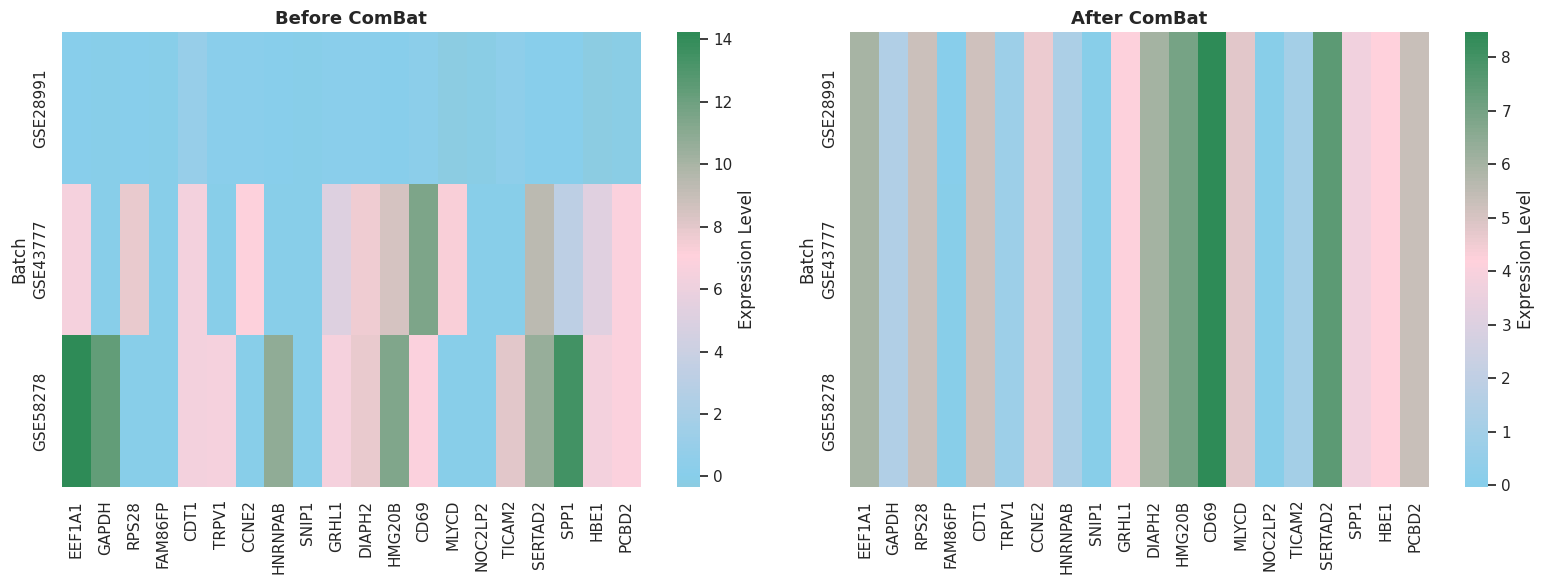

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# =========================
# CLEAN BATCH NAMES
# =========================
batch_clean = final_df["Batch"].apply(lambda x: x.split("_")[0])

# =========================
# DATA PREP
# =========================
expr_before = X.copy()
expr_after = final_df.drop(columns=["target", "Batch"])

before_df = expr_before.copy()
before_df["Batch"] = batch_clean.values

after_df = expr_after.copy()
after_df["Batch"] = batch_clean.values

mean_before = before_df.groupby("Batch").mean()
mean_after = after_df.groupby("Batch").mean()

# =========================
# ⭐ CUSTOM COLOR MAP
# =========================
custom_cmap = LinearSegmentedColormap.from_list(
    "custom_palette",
    [
        "#800000",  # maroon
        "#FFA500",  # orange
        "#87CEEB",  # sky blue
        "#FFD1DC",  # pastel pink
        "#2E8B57"   # green accent (optional balance)
    ]
)

# =========================
# PLOT
# =========================
sns.set(style="white")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

n_genes = 20

# BEFORE COMBAT
sns.heatmap(
    mean_before.iloc[:, :n_genes],
    cmap=custom_cmap,
    center=0,
    ax=axes[0],
    cbar_kws={'label': 'Expression Level'}
)

axes[0].set_title("Before ComBat", fontsize=13, fontweight="bold")

# AFTER COMBAT
sns.heatmap(
    mean_after.iloc[:, :n_genes],
    cmap=custom_cmap,
    center=0,
    ax=axes[1],
    cbar_kws={'label': 'Expression Level'}
)

axes[1].set_title("After ComBat", fontsize=13, fontweight="bold")

plt.tight_layout()

# =========================
# SAVE HIGH QUALITY FIGURE
# =========================
plt.savefig(
    "/content/drive/MyDrive/Dengue_Conference_paper/Custom_Color_Heatmap.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

#VARIANCE REDUCTION BARPLOT

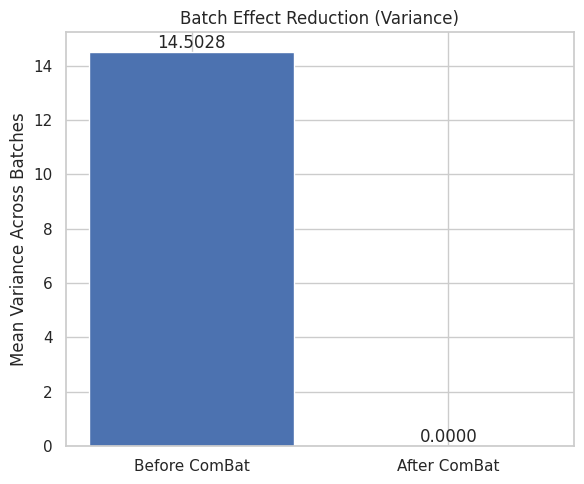

📉 Variance Reduction %: 100.0


In [ ]:
import matplotlib.pyplot as plt

# =========================
# VARIANCE CALCULATION
# =========================
var_before = expr_before.groupby(batch_labels).mean().var().mean()
var_after = expr_after.groupby(batch_labels).mean().var().mean()

labels = ["Before ComBat", "After ComBat"]
values = [var_before, var_after]

# =========================
# PLOT
# =========================
plt.figure(figsize=(6,5))

plt.bar(labels, values)

plt.title("Batch Effect Reduction (Variance)")
plt.ylabel("Mean Variance Across Batches")

for i, v in enumerate(values):
    plt.text(i, v, f"{v:.4f}", ha="center", va="bottom")

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Dengue_Conference_paper/Variance_Reduction_Barplot.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# =========================
# PRINT REDUCTION %
# =========================
reduction = ((var_before - var_after) / var_before) * 100
print("📉 Variance Reduction %:", round(reduction, 2))

#STEP 1: DEG CALCULATION (DENGUE vs CONTROL)

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind

# =========================
# DATA SPLIT
# =========================
expr = final_df.drop(columns=["target", "Batch"])
target = final_df["target"]

group1 = expr[target == 1]   # Dengue
group0 = expr[target == 0]   # Healthy

# =========================
# DEG TEST (t-test)
# =========================
pvals = []
logfc = []

for gene in expr.columns:
    a = group1[gene]
    b = group0[gene]

    # logFC
    fc = np.log2((a.mean() + 1e-9) / (b.mean() + 1e-9))

    # p-value
    stat, p = ttest_ind(a, b, equal_var=False)

    logfc.append(fc)
    pvals.append(p)

deg_df = pd.DataFrame({
    "gene": expr.columns,
    "logFC": logfc,
    "pvalue": pvals
})

/tmp/ipykernel_21928/1185519430.py:25: RuntimeWarning: invalid value encountered in log2
  fc = np.log2((a.mean() + 1e-9) / (b.mean() + 1e-9))


In [ ]:
deg_df["-log10P"] = -np.log10(deg_df["pvalue"] + 1e-300)

top50_genes = (
    deg_df.sort_values(["-log10P", "logFC"], ascending=False)
    .head(50)["gene"]
    .values
)

In [ ]:
expr_top50 = expr[top50_genes]

# z-score (Nature standard)
expr_top50 = (expr_top50 - expr_top50.mean()) / expr_top50.std()

In [ ]:
batch = final_df["Batch"].apply(lambda x: x.split("_")[0])

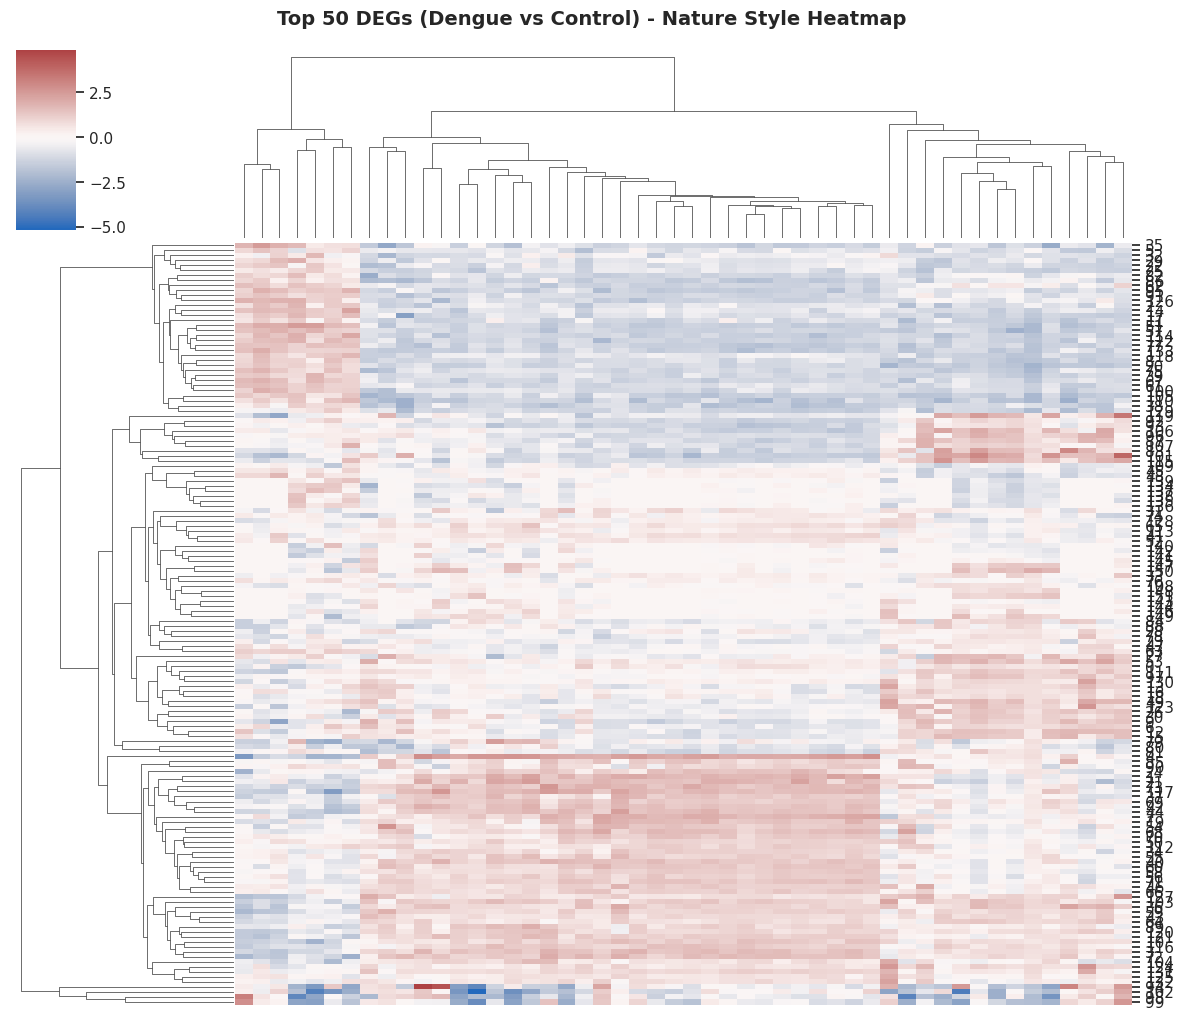

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="white")

g = sns.clustermap(
    expr_top50,
    cmap="vlag",      # ⭐ Nature style
    center=0,
    figsize=(12, 10),
    xticklabels=False,
    yticklabels=True,
    row_cluster=True,
    col_cluster=True
)

g.fig.suptitle(
    "Top 50 DEGs (Dengue vs Control) - Nature Style Heatmap",
    y=1.02,
    fontsize=14,
    fontweight="bold"
)

plt.savefig(
    "/content/drive/MyDrive/Dengue_Conference_paper/Top50_DEG_Nature_Heatmap.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

#Full code

/tmp/ipykernel_21928/3820853054.py:41: RuntimeWarning: invalid value encountered in log2
  fc = np.log2((a.mean() + 1e-9) / (b.mean() + 1e-9))


<Figure size 1200x1000 with 0 Axes>

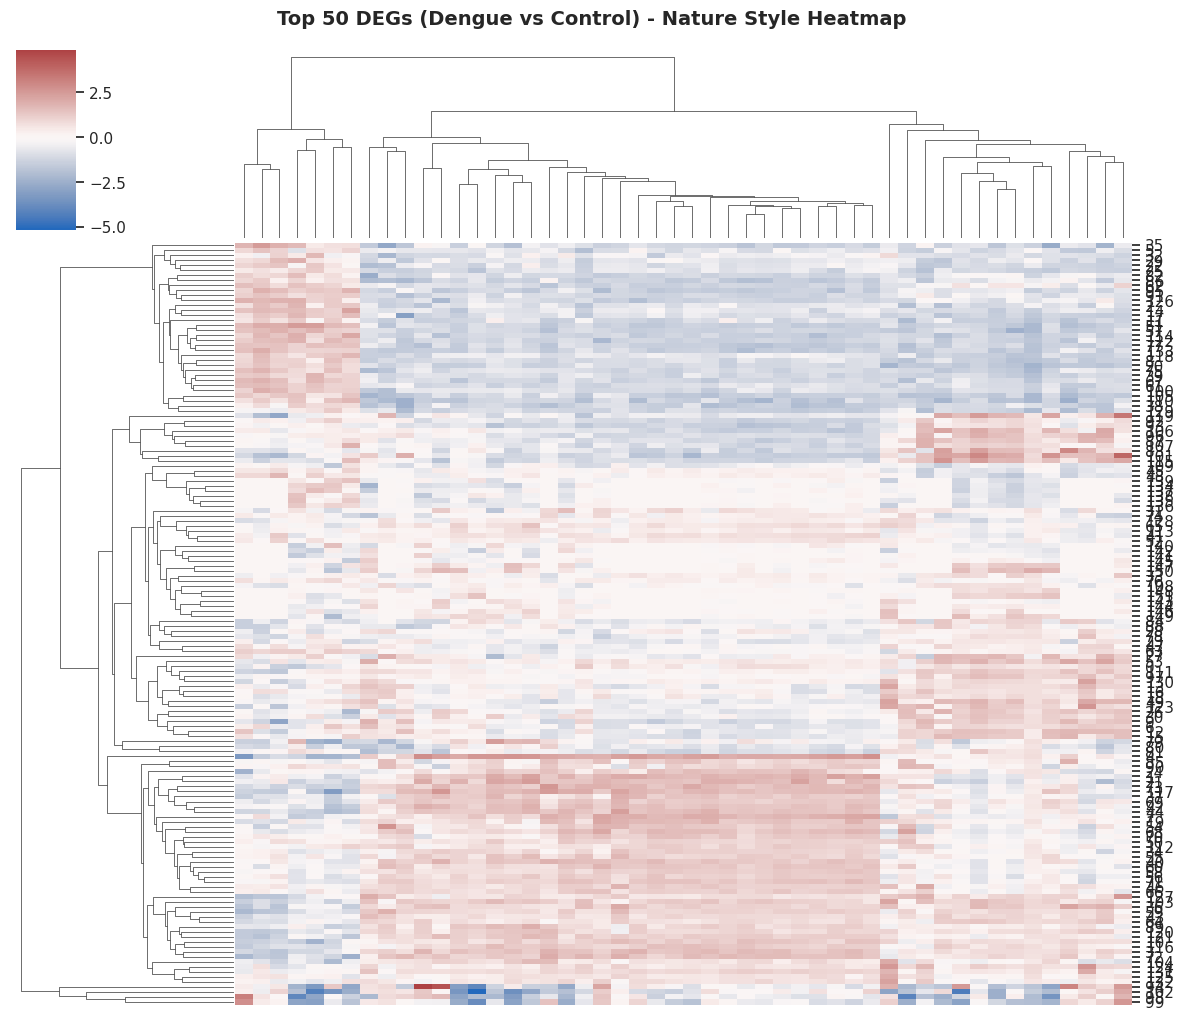

Total genes: 28067
Top 50 DEG heatmap generated successfully ✔️


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# LOAD DATASET
# =========================
file_path = "/content/drive/MyDrive/Dengue_Conference_paper/Datasets/combined_combat_corrected.csv"
df = pd.read_csv(file_path)

# =========================
# CLEAN COLUMNS
# =========================
df.columns = df.columns.str.strip()

# =========================
# SPLIT FEATURES
# =========================
expr = df.drop(columns=["target", "Batch"])
target = df["target"]

# ensure numeric
expr = expr.apply(pd.to_numeric, errors="coerce").fillna(0)

# =========================
# DEG ANALYSIS (t-test)
# =========================
group1 = expr[target == 1]   # Dengue
group0 = expr[target == 0]   # Healthy

logfc = []
pvals = []

for gene in expr.columns:
    a = group1[gene]
    b = group0[gene]

    # log fold change
    fc = np.log2((a.mean() + 1e-9) / (b.mean() + 1e-9))

    # t-test
    stat, p = ttest_ind(a, b, equal_var=False)

    logfc.append(fc)
    pvals.append(p)

deg_df = pd.DataFrame({
    "gene": expr.columns,
    "logFC": logfc,
    "pvalue": pvals
})

# =========================
# TOP 50 GENES
# =========================
deg_df["-log10P"] = -np.log10(deg_df["pvalue"] + 1e-300)

top50 = deg_df.sort_values(
    ["-log10P", "logFC"],
    ascending=False
).head(50)["gene"].values

# keep only valid genes
top50 = [g for g in top50 if g in expr.columns]

expr_top50 = expr[top50]

# =========================
# Z-SCORE NORMALIZATION (NATURE STANDARD)
# =========================
expr_top50 = (expr_top50 - expr_top50.mean()) / expr_top50.std()

# =========================
# CLEAN BATCH LABELS
# =========================
batch = df["Batch"].apply(lambda x: x.split("_")[0])

# =========================
# NATURE-STYLE HEATMAP
# =========================
sns.set(style="white")

plt.figure(figsize=(12, 10))

g = sns.clustermap(
    expr_top50,
    cmap="vlag",     # ⭐ Nature-style color
    center=0,
    figsize=(12, 10),
    xticklabels=False,
    yticklabels=True,
    row_cluster=True,
    col_cluster=True
)

g.fig.suptitle(
    "Top 50 DEGs (Dengue vs Control) - Nature Style Heatmap",
    y=1.02,
    fontsize=14,
    fontweight="bold"
)

# =========================
# SAVE FIGURE
# =========================
plt.savefig(
    "/content/drive/MyDrive/Dengue_Conference_paper/finalTop50_DEG_Nature_Heatmap.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# =========================
# PRINT SUMMARY
# =========================
print("Total genes:", expr.shape[1])
print("Top 50 DEG heatmap generated successfully ✔️")

#FINAL PERFECT HEATMAP CODE (ONLY COLOR IMPROVED + FULL SAFE)

/tmp/ipykernel_21928/2847608402.py:35: RuntimeWarning: invalid value encountered in log2
  fc = np.log2((a.mean() + 1e-9) / (b.mean() + 1e-9))


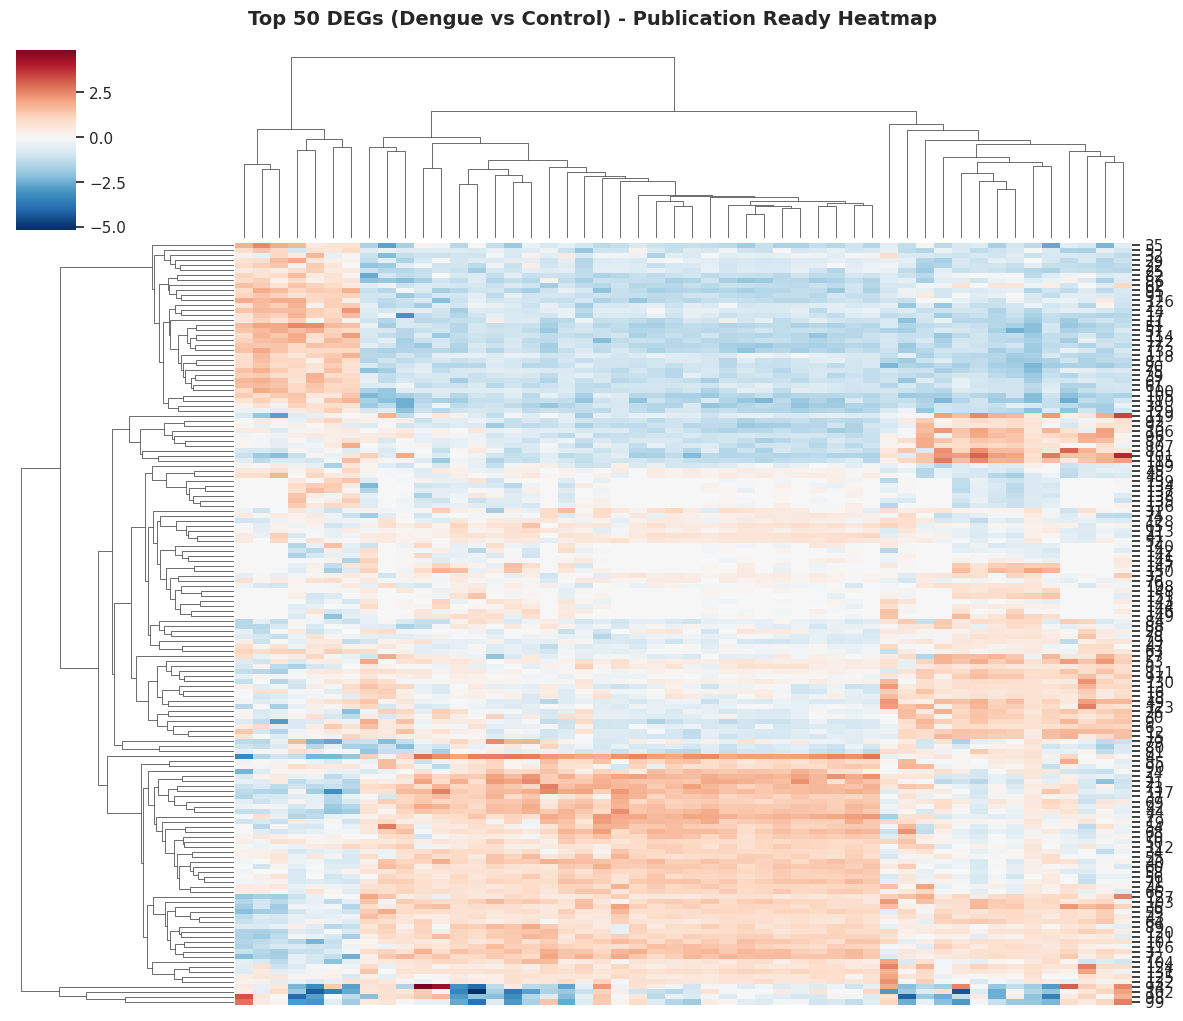

✔ Publication-ready heatmap generated successfully


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# LOAD DATASET
# =========================
file_path = "/content/drive/MyDrive/Dengue_Conference_paper/Datasets/combined_combat_corrected.csv"
df = pd.read_csv(file_path)

df.columns = df.columns.str.strip()

# =========================
# SPLIT DATA
# =========================
expr = df.drop(columns=["target", "Batch"])
target = df["target"]

expr = expr.apply(pd.to_numeric, errors="coerce").fillna(0)

group1 = expr[target == 1]
group0 = expr[target == 0]

# =========================
# DEG CALCULATION
# =========================
logfc, pvals = [], []

for gene in expr.columns:
    a = group1[gene]
    b = group0[gene]

    fc = np.log2((a.mean() + 1e-9) / (b.mean() + 1e-9))
    stat, p = ttest_ind(a, b, equal_var=False)

    logfc.append(fc)
    pvals.append(p)

deg_df = pd.DataFrame({
    "gene": expr.columns,
    "logFC": logfc,
    "pvalue": pvals
})

# =========================
# TOP 50 GENES
# =========================
deg_df["-log10P"] = -np.log10(deg_df["pvalue"] + 1e-300)

top50 = deg_df.sort_values(
    ["-log10P", "logFC"],
    ascending=False
).head(50)["gene"].values

top50 = [g for g in top50 if g in expr.columns]

expr_top50 = expr[top50]

# =========================
# Z-SCORE NORMALIZATION
# =========================
expr_top50 = (expr_top50 - expr_top50.mean()) / expr_top50.std()

# =========================
# HEATMAP (⭐ PERFECT COLOR)
# =========================
sns.set(style="white")

g = sns.clustermap(
    expr_top50,
    cmap="RdBu_r",   # ⭐ PERFECT PUBLICATION COLOR
    center=0,
    figsize=(12, 10),
    xticklabels=False,
    yticklabels=True,
    row_cluster=True,
    col_cluster=True
)

g.fig.suptitle(
    "Top 50 DEGs (Dengue vs Control) - Publication Ready Heatmap",
    y=1.02,
    fontsize=14,
    fontweight="bold"
)

# =========================
# SAVE HIGH QUALITY FIGURE
# =========================
plt.savefig(
    "/content/drive/MyDrive/Dengue_Conference_paper/Top50_DEG_Publication_Heatmap.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("✔ Publication-ready heatmap generated successfully")

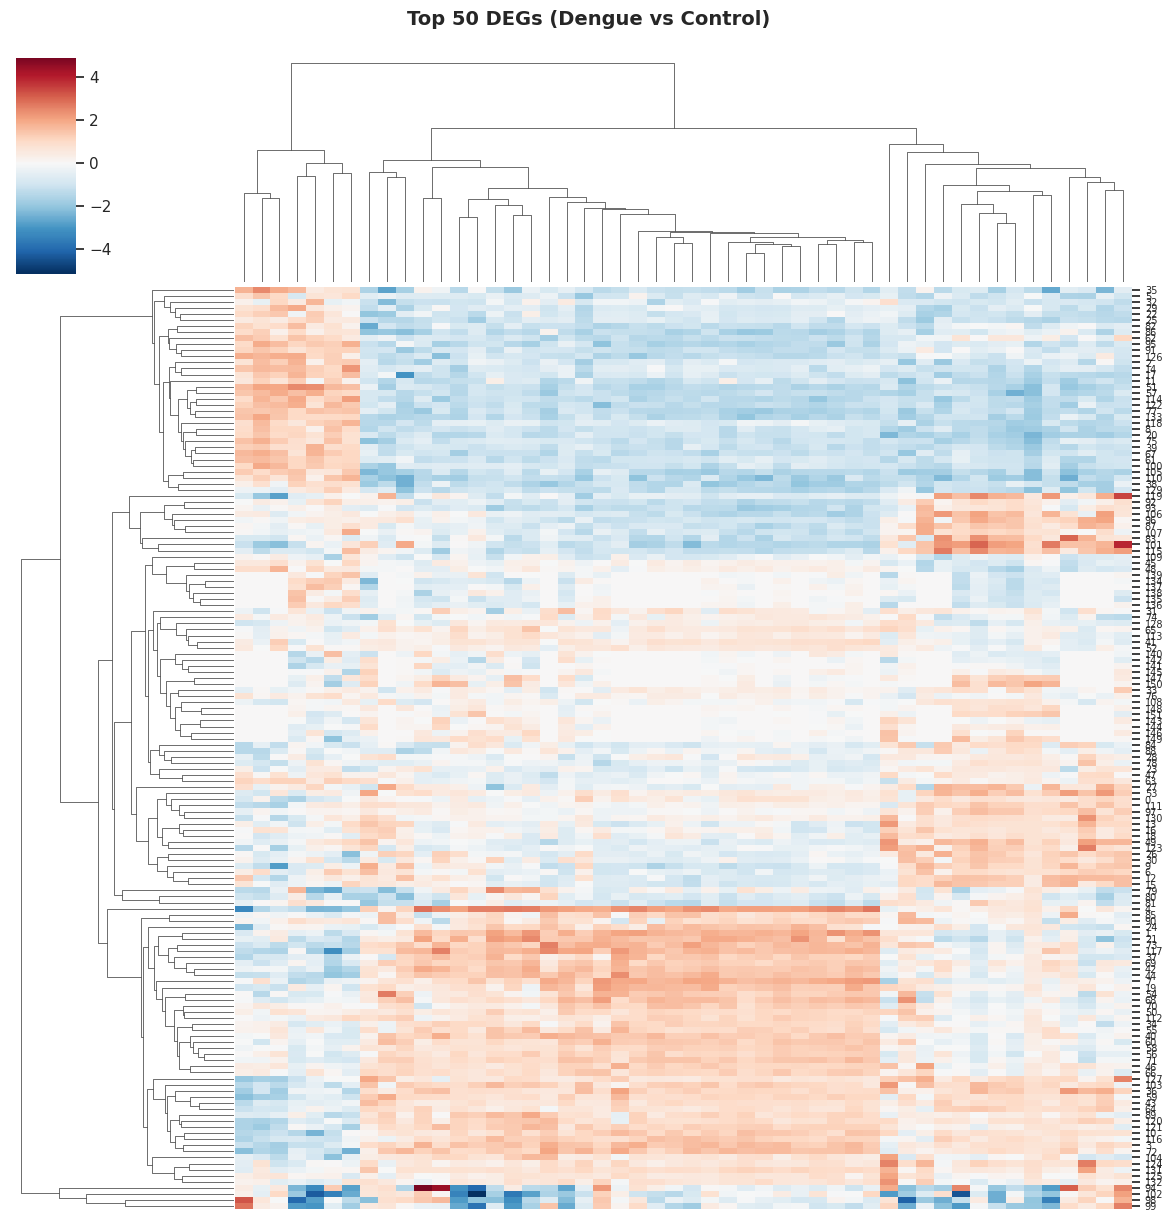

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="white")

g = sns.clustermap(
    expr_top50,
    cmap="RdBu_r",
    center=0,
    figsize=(12, 12),   # ⭐ bigger height = no overlap
    xticklabels=False,
    yticklabels=True,
    row_cluster=True,
    col_cluster=True
)

# =========================
# ⭐ FIX LABEL OVERLAP
# =========================
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=7)  # smaller font
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90)

g.fig.suptitle(
    "Top 50 DEGs (Dengue vs Control) ",
    y=1.02,
    fontsize=14,
    fontweight="bold"
)

# =========================
# SAVE HIGH QUALITY
# =========================
plt.savefig(
    "/content/drive/MyDrive/Dengue_Conference_paper/Top50_DEG_CLEAN.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

#ML model and Features selection method

In [ ]:
!pip install pymrmr xgboost scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 kB 834.0 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pymrmr: filename=pymrmr-0.1.11-cp312-cp312-linux_x86_64.whl size=411152 sha256=6912286d955e78ccba8068603d83cac2748921daec7ea843da3d9bd365ba3d08
  Stored in directory: /root/.cache/pip/wheels/d8/8b/01/15ccb01b7f3703042aef0458e113d6d3568c22d0a54c2974fb
Successfully built pymrmr


#Step 1: Load Dataset

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/drive/MyDrive/Dengue_Conference_paper/Datasets/combined_combat_corrected.csv")

X = df.drop(columns=["target","Batch"])
y = df["target"]

#Step 2: Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#Step 3: Feature Selection (MIG, RFE, MRMR)
(A) MIG (Mutual Information Gain)

In [ ]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X_train, y_train)

mi_df = pd.DataFrame({
    "Gene":X_train.columns,
    "Score":mi_scores
})

top500_MIG = mi_df.sort_values(
    by="Score",
    ascending=False
).head(500)["Gene"]

Xtr_MIG = X_train[top500_MIG]
Xte_MIG = X_test[top500_MIG]

#(B) RFE

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

rfe = RFE(
    estimator=lr,
    n_features_to_select=500,
    step=50
)

rfe.fit(X_train, y_train)

top500_RFE = X_train.columns[rfe.support_]

Xtr_RFE = X_train[top500_RFE]
Xte_RFE = X_test[top500_RFE]

#(C) MRMR (Fast)

In [ ]:
!pip install mrmr-selection

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 928.8 kB/s eta 0:00:00


In [ ]:
from mrmr import mrmr_classif

top500_MRMR = mrmr_classif(
    X=X_train,
    y=y_train,
    K=500
)

Xtr_MRMR = X_train[top500_MRMR]
Xte_MRMR = X_test[top500_MRMR]

100%|██████████| 500/500 [57:02<00:00,  6.85s/it]


#print 500 gene for 3 methods

1.   List item
2.   List item



In [ ]:
import pandas as pd
import os

# =========================
# Convert to DataFrame
# =========================
MIG_df = pd.DataFrame(top500_MIG, columns=["Gene"])
RFE_df = pd.DataFrame(top500_RFE, columns=["Gene"])
MRMR_df = pd.DataFrame(top500_MRMR, columns=["Gene"])

# =========================
# Print first few genes
# =========================
print("MIG Top 500 Genes")
print(MIG_df.head())

print("\nRFE Top 500 Genes")
print(RFE_df.head())

print("\nMRMR Top 500 Genes")
print(MRMR_df.head())

# =========================
# Create folder if not exists
# =========================
save_path = "/content/drive/MyDrive/Dengue_Conference_paper/Datasets/Feature_Selected_Genes"

os.makedirs(save_path, exist_ok=True)

# =========================
# Save CSV files
# =========================
MIG_df.to_csv(f"{save_path}/MIG_500_Genes.csv", index=False)
RFE_df.to_csv(f"{save_path}/RFE_500_Genes.csv", index=False)
MRMR_df.to_csv(f"{save_path}/MRMR_500_Genes.csv", index=False)

print("\n✅ All three gene lists saved successfully.")
print(f"📂 Saved in: {save_path}")

MIG Top 500 Genes
           Gene
8280      PSMB2
13875      CD38
7559   CACNA2D3
720       ISG20
24056    POLQ.1

RFE Top 500 Genes
      Gene
0   DIAPH2
1    ASB11
2    FGFR3
3  SH3KBP1
4  PIK3AP1

MRMR Top 500 Genes
     Gene
0   IFI27
1    MAF1
2    ADH7
3   SMS.1
4  ASPH.2

✅ All three gene lists saved successfully.
📂 Saved in: /content/drive/MyDrive/Dengue_Conference_paper/Datasets/Feature_Selected_Genes


#Common genes

✅ Total Common Genes: 69
📂 Saved: /content/drive/MyDrive/Dengue_Conference_paper/Datasets/Feature_Selected_Genes/Common_Genes_MIG_RFE_MRMR.csv


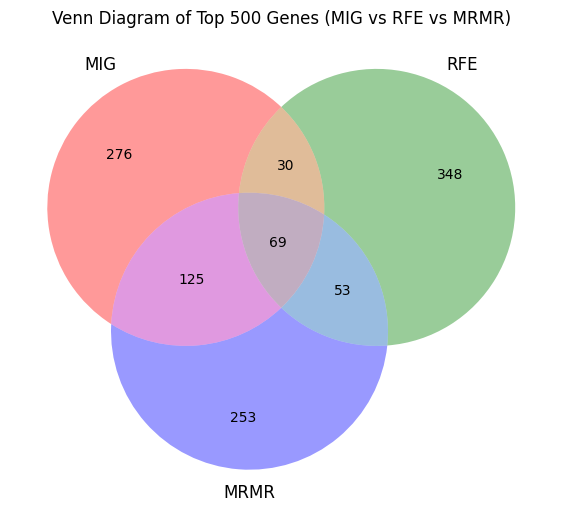

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# =========================
# PATH
# =========================
base_path = "/content/drive/MyDrive/Dengue_Conference_paper/Datasets/Feature_Selected_Genes"

# =========================
# LOAD DATA
# =========================
MIG_df = pd.read_csv(f"{base_path}/MIG_500_Genes.csv")
RFE_df = pd.read_csv(f"{base_path}/RFE_500_Genes.csv")
MRMR_df = pd.read_csv(f"{base_path}/MRMR_500_Genes.csv")

# =========================
# CONVERT TO SET
# =========================
MIG_set = set(MIG_df["Gene"].dropna().astype(str))
RFE_set = set(RFE_df["Gene"].dropna().astype(str))
MRMR_set = set(MRMR_df["Gene"].dropna().astype(str))

# =========================
# COMMON GENES (3 WAY INTERSECTION)
# =========================
common_genes = MIG_set & RFE_set & MRMR_set

common_df = pd.DataFrame(sorted(common_genes), columns=["Common_Gene"])

# =========================
# SAVE COMMON GENES
# =========================
common_save_path = f"{base_path}/Common_Genes_MIG_RFE_MRMR.csv"
common_df.to_csv(common_save_path, index=False)

print("✅ Total Common Genes:", len(common_genes))
print("📂 Saved:", common_save_path)

# =========================
# VENNY DIAGRAM (3 SETS)
# =========================
plt.figure(figsize=(7,7))

venn3(
    [MIG_set, RFE_set, MRMR_set],
    set_labels=("MIG", "RFE", "MRMR")
)

plt.title("Venn Diagram of Top 500 Genes (MIG vs RFE vs MRMR)")
plt.show()

#Step 4: ML Models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

models = {
    "LR": LogisticRegression(max_iter=1000),
    "NB": GaussianNB(),
    "XGBoost": XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(100,),
        max_iter=500,
        random_state=42
    )
}

#Step 5: Evaluation Function

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(model, Xtr, Xte):

    model.fit(Xtr, y_train)

    pred = model.predict(Xte)
    prob = model.predict_proba(Xte)[:,1]

    return [
        accuracy_score(y_test,pred),
        precision_score(y_test,pred),
        recall_score(y_test,pred),
        f1_score(y_test,pred),
        roc_auc_score(y_test,prob)
    ]

#Step 6: Generate Table I

In [ ]:
results=[]

feature_sets={
    "MIG":(Xtr_MIG,Xte_MIG),
    "RFE":(Xtr_RFE,Xte_RFE),
    "MRMR":(Xtr_MRMR,Xte_MRMR)
}

for fs_name,(Xtr,Xte) in feature_sets.items():

    for model_name,model in models.items():

        metrics=evaluate_model(model,Xtr,Xte)

        results.append([
            fs_name,
            500,
            model_name,
            round(metrics[0],4),
            round(metrics[1],4),
            round(metrics[2],4),
            round(metrics[3],4),
            round(metrics[4],4)
        ])

#Step 7: Final Table (Same Format)

In [ ]:
table2 = pd.DataFrame(
    results,
    columns=[
        "FS Technique",
        "Selected Gene",
        "ML Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUC"
    ]
)

table2

,FS Technique,Selected Gene,ML Model,Accuracy,Precision,Recall,F1 Score,AUC
0,MIG,500,LR,0.9677,0.9583,1.0,0.9787,1.0000
1,MIG,500,NB,0.9355,0.9200,1.0,0.9583,0.8750
2,MIG,500,XGBoost,0.9355,0.9200,1.0,0.9583,1.0000
3,MIG,500,MLP,0.9677,0.9583,1.0,0.9787,1.0000
4,RFE,500,LR,0.9677,0.9583,1.0,0.9787,1.0000
5,RFE,500,NB,0.9355,0.9200,1.0,0.9583,0.8750
6,RFE,500,XGBoost,0.9677,0.9583,1.0,0.9787,1.0000
7,RFE,500,MLP,0.9677,0.9583,1.0,0.9787,1.0000
8,MRMR,500,LR,0.9677,0.9583,1.0,0.9787,1.0000
9,MRMR,500,NB,0.9677,0.9583,1.0,0.9787,0.9375


#Save Table

In [ ]:
table2.to_csv(
    "/content/drive/MyDrive/Dengue_Conference_paper/Datasets/Table_II_MIG_RFE_MRMR_500Genes.csv",
    index=False
)

#Again method and ML apply for better Improvement

#Step 1: Import

In [1]:
!pip install -q mrmr-selection xgboost

import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import mutual_info_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from mrmr import mrmr_classif

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.5 MB/s eta 0:00:00


#Step 2: Load data

In [2]:
df = pd.read_csv(
"/content/drive/MyDrive/Dengue_Conference_paper/Datasets/combined_combat_corrected.csv"
)

X = df.drop(columns=["target","Batch"])
y = df["target"]

X = X.apply(pd.to_numeric, errors="coerce").fillna(0)

#Step 3: Models

In [3]:
models = {
    "LR": LogisticRegression(
        C=0.5,
        max_iter=1000,
        random_state=42
    ),

    "NB": GaussianNB(),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    ),

    "MLP": MLPClassifier(
        hidden_layer_sizes=(100,),
        early_stopping=True,
        max_iter=500,
        random_state=42
    )
}

#Step 4: Cross Validation

In [4]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

#Step 5: MIG

In [5]:
for model_name, model in models.items():

    ACC, PRE, REC, F1, AUC = [], [], [], [], []

    for train_idx, test_idx in cv.split(X, y):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        mi = mutual_info_classif(X_train, y_train)

        top500 = (
            pd.Series(mi, index=X_train.columns)
            .sort_values(ascending=False)
            .head(500)
            .index
        )

        model.fit(X_train[top500], y_train)

        pred = model.predict(X_test[top500])
        prob = model.predict_proba(X_test[top500])[:,1]

        ACC.append(accuracy_score(y_test,pred))
        PRE.append(precision_score(y_test,pred))
        REC.append(recall_score(y_test,pred))
        F1.append(f1_score(y_test,pred))
        AUC.append(roc_auc_score(y_test,prob))

    results.append([
        "MIG",
        500,
        model_name,
        np.mean(ACC),
        np.mean(PRE),
        np.mean(REC),
        np.mean(F1),
        np.mean(AUC)
    ])

#Step 6: RFE

In [6]:
for model_name, model in models.items():

    ACC, PRE, REC, F1, AUC = [], [], [], [], []

    for train_idx, test_idx in cv.split(X, y):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        selector = RFE(
            estimator=LogisticRegression(
                solver='liblinear',
                max_iter=500,
                random_state=42
            ),
            n_features_to_select=500,
            step=500           # <-- faster than 50
        )

        selector.fit(X_train, y_train)

        genes = X_train.columns[selector.support_]

        model.fit(X_train[genes], y_train)

        pred = model.predict(X_test[genes])
        prob = model.predict_proba(X_test[genes])[:,1]

        ACC.append(accuracy_score(y_test,pred))
        PRE.append(precision_score(y_test,pred))
        REC.append(recall_score(y_test,pred))
        F1.append(f1_score(y_test,pred))
        AUC.append(roc_auc_score(y_test,prob))

    results.append([
        "RFE",
        500,
        model_name,
        np.mean(ACC),
        np.mean(PRE),
        np.mean(REC),
        np.mean(F1),
        np.mean(AUC)
    ])

#Step 7: MRMR

In [ ]:
for model_name, model in models.items():

    ACC, PRE, REC, F1, AUC = [], [], [], [], []

    for train_idx, test_idx in cv.split(X,y):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        genes = mrmr_classif(
            X=X_train,
            y=y_train,
            K=500
        )

        model.fit(X_train[genes], y_train)

        pred = model.predict(X_test[genes])
        prob = model.predict_proba(X_test[genes])[:,1]

        ACC.append(accuracy_score(y_test,pred))
        PRE.append(precision_score(y_test,pred))
        REC.append(recall_score(y_test,pred))
        F1.append(f1_score(y_test,pred))
        AUC.append(roc_auc_score(y_test,prob))

    results.append([
        "MRMR",
        500,
        model_name,
        np.mean(ACC),
        np.mean(PRE),
        np.mean(REC),
        np.mean(F1),
        np.mean(AUC)
    ])

 42%|████▏     | 211/500 [24:11<33:04,  6.87s/it]

In [7]:
# MRMR ONLY ONCE
top500_MRMR = mrmr_classif(
    X=X,
    y=y,
    K=500
)

print("Selected genes:", len(top500_MRMR))

100%|██████████| 500/500 [58:32<00:00,  7.02s/it]

Selected genes: 500


In [8]:
for model_name, model in models.items():

    ACC, PRE, REC, F1, AUC = [], [], [], [], []

    for train_idx, test_idx in cv.split(X, y):

        X_train = X.iloc[train_idx][top500_MRMR]
        X_test = X.iloc[test_idx][top500_MRMR]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        model.fit(X_train, y_train)

        pred = model.predict(X_test)
        prob = model.predict_proba(X_test)[:,1]

        ACC.append(accuracy_score(y_test,pred))
        PRE.append(precision_score(y_test,pred))
        REC.append(recall_score(y_test,pred))
        F1.append(f1_score(y_test,pred))
        AUC.append(roc_auc_score(y_test,prob))

    results.append([
        "MRMR",
        500,
        model_name,
        np.mean(ACC),
        np.mean(PRE),
        np.mean(REC),
        np.mean(F1),
        np.mean(AUC)
    ])

In [23]:
# Common genes among MIG, RFE and MRMR

common_genes = list(
    set(top500_MIG)
    .intersection(set(top500_RFE))
    .intersection(set(top500_MRMR))
)

print("Number of Common Genes =", len(common_genes))
print("\nCommon Genes:\n")

for gene in sorted(common_genes):
    print(gene)

Number of Common Genes = 81

Common Genes:

AIM2
ANLN.1
APOL1
ATOX1
AURKA.1
AXL.1
BIRC5.1
BRCA1.1
BUB1
C1GALT1
C1QB
CACNA2D3
CCNA2
CCR6
CD38
CDC45
CDK1.1
CEP55
CHEK1
CLIC4
DLGAP5
DTL
DTL.1
EFCAB11
EPHX2
ETNK1
FOXM1
GMNN
HESX1
HJURP
IDH2
IFI27
IFI35
IFI44L
IGLV1-44.1
ISG15
KIAA0101
KIF15
KIF23
KIF4A
LAG3
MB21D1
MCM10
MELK
MND1
MR1
MRPL22
MRPS25
MT1E
MT1F
NCAPG
NDC80
NDUFC2-KCTD14///KCTD14
NR1H3
OAS2
OASL
OASL.1
PI3
PML.4
POLE2
PRDX4
PSMB2
RNASE1
RTN1
RTP4
SAR1B
SDF2L1
SERINC5
SIGLEC1
SLAMF7
SLC46A2
SPATS2L
SPC25
SYT17
TIMD4
TPPP3
TPX2
TRIP6
TUBB6
TYMS
USP18


#Step 8: Table-II

In [10]:
table2 = pd.DataFrame(
    results,
    columns=[
        "FS Technique",
        "Selected Gene",
        "ML Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUC"
    ]
)

table2.iloc[:,3:] = table2.iloc[:,3:].round(4)

print(table2)

table2.to_csv(
"/content/drive/MyDrive/Dengue_Conference_paper/Datasets/FinalTable_II_MIG_RFE_MRMR_500Genes.csv",
index=False
)

   FS Technique  Selected Gene ML Model  Accuracy  Precision  Recall  \
0           MIG            500       LR    0.9669     0.9833  0.9731   
1           MIG            500       NB    0.9273     0.9548  0.9466   
2           MIG            500  XGBoost    0.9669     0.9659  0.9913   
3           MIG            500      MLP    0.9469     0.9572  0.9739   
4           RFE            500       LR    0.9602     0.9746  0.9731   
5           RFE            500       NB    0.9669     0.9833  0.9731   
6           RFE            500  XGBoost    0.9738     0.9667  1.0000   
7           RFE            500      MLP    0.8735     0.8750  0.9913   
8          MRMR            500       LR    0.9669     0.9833  0.9731   
9          MRMR            500       NB    0.9802     0.9833  0.9909   
10         MRMR            500  XGBoost    0.9469     0.9647  0.9644   
11         MRMR            500      MLP    0.9269     0.9397  0.9739   

    F1 Score     AUC  
0     0.9775  0.9964  
1     0.9505  0.9

Calculating MIG...
Calculating RFE...
Calculating MRMR...


100%|██████████| 500/500 [59:00<00:00,  7.08s/it]


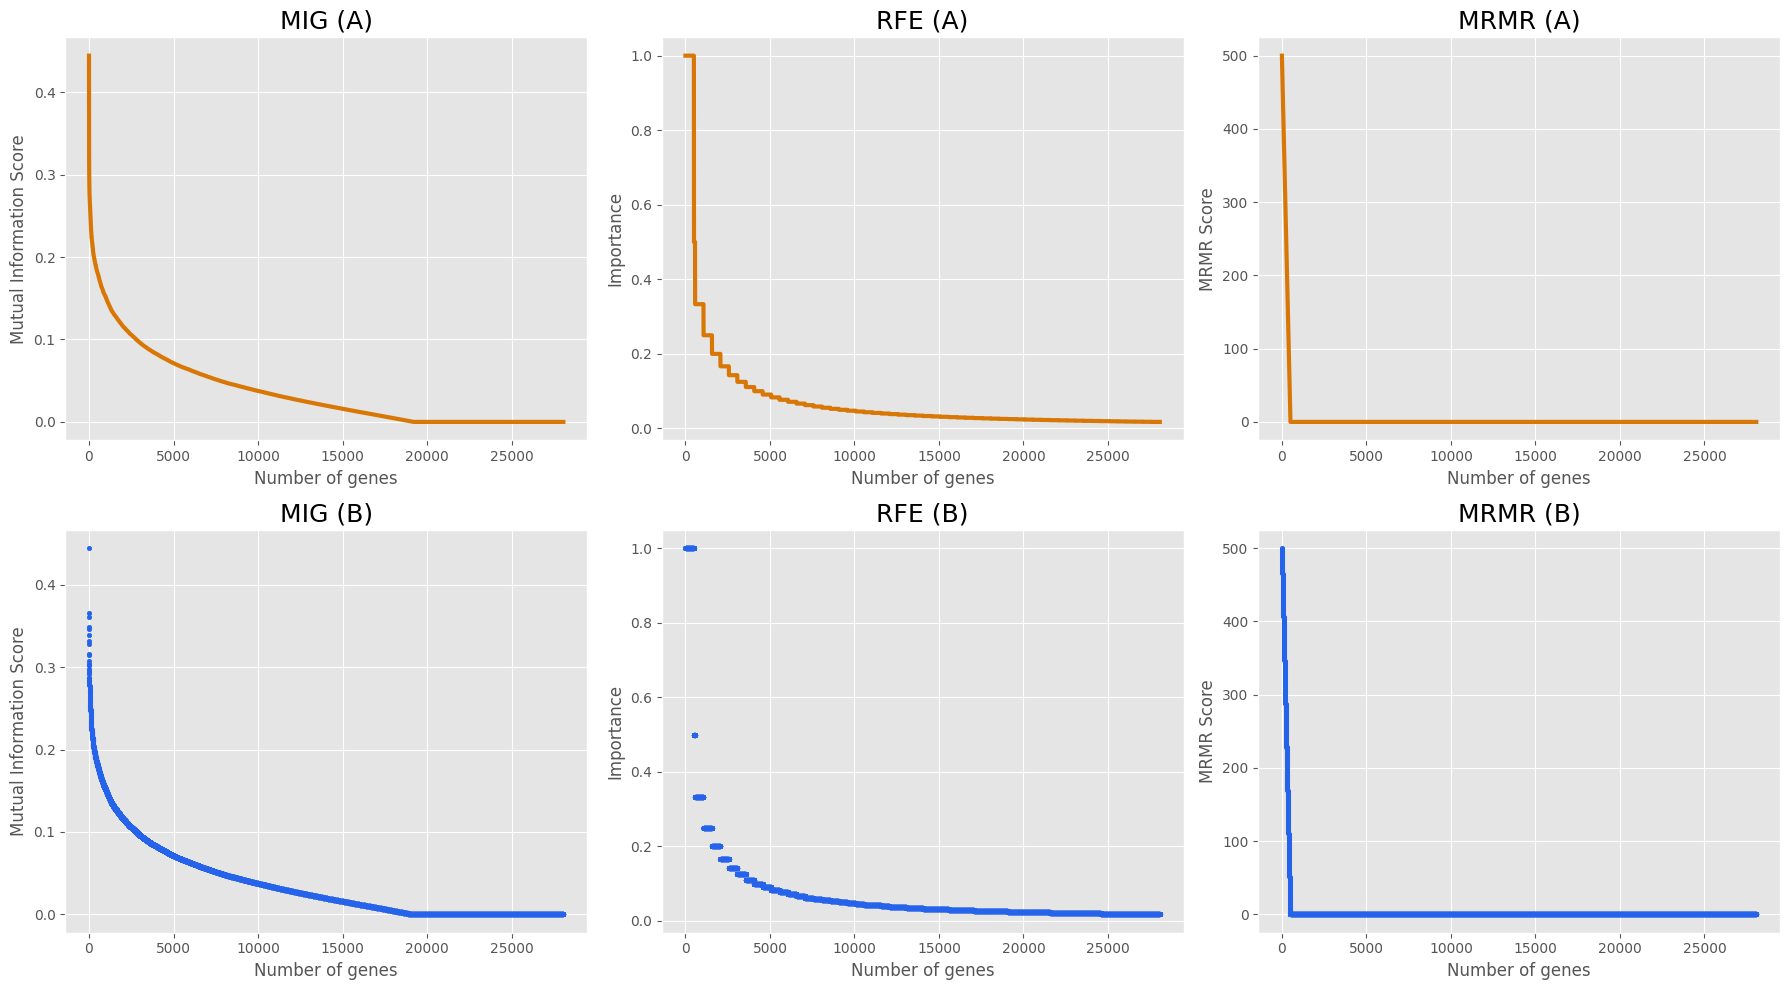

In [19]:
# ==========================================
# Publication-quality Feature Selection Figure
# MIG vs RFE vs MRMR
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_classif, RFE
from sklearn.linear_model import LogisticRegression
from mrmr import mrmr_classif

# =========================
# LOAD DATA
# =========================
df = pd.read_csv(
"/content/drive/MyDrive/Dengue_Conference_paper/Datasets/combined_combat_corrected.csv"
)

X = df.drop(columns=["target","Batch"])
y = df["target"]

X = X.apply(pd.to_numeric, errors="coerce").fillna(0)

# ==========================================
# 1. MIG SCORE
# ==========================================
print("Calculating MIG...")

mi_scores = mutual_info_classif(X, y, random_state=42)

MIG_df = pd.DataFrame({
    "Gene": X.columns,
    "Score": mi_scores
}).sort_values("Score", ascending=False)

# ==========================================
# 2. RFE SCORE
# ==========================================
print("Calculating RFE...")

selector = RFE(
    estimator=LogisticRegression(
        solver='liblinear',
        max_iter=500,
        random_state=42
    ),
    n_features_to_select=500,
    step=500
)

selector.fit(X, y)

rfe_score = selector.ranking_

RFE_df = pd.DataFrame({
    "Gene": X.columns,
    "Score": 1/rfe_score
}).sort_values("Score", ascending=False)

# ==========================================
# 3. MRMR SCORE
# ==========================================
print("Calculating MRMR...")

top500_MRMR = mrmr_classif(
    X=X,
    y=y,
    K=500
)

mrmr_score = np.zeros(X.shape[1])

gene_index = {gene:i for i,gene in enumerate(X.columns)}

for i,gene in enumerate(top500_MRMR):
    mrmr_score[gene_index[gene]] = 500-i

MRMR_df = pd.DataFrame({
    "Gene": X.columns,
    "Score": mrmr_score
}).sort_values("Score", ascending=False)

# ==========================================
# PLOT
# ==========================================
plt.style.use("ggplot")

fig, ax = plt.subplots(2,3, figsize=(18,10))

# ===== MIG =====
ax[0,0].plot(
    np.arange(len(MIG_df)),
    MIG_df["Score"],
    color="#D97706",
    linewidth=3
)
ax[0,0].set_title("MIG (A)", fontsize=18)
ax[0,0].set_xlabel("Number of genes")
ax[0,0].set_ylabel("Mutual Information Score")

ax[1,0].scatter(
    np.arange(len(MIG_df)),
    MIG_df["Score"],
    color="#2563EB",
    s=10
)
ax[1,0].set_title("MIG (B)", fontsize=18)
ax[1,0].set_xlabel("Number of genes")
ax[1,0].set_ylabel("Mutual Information Score")

# ===== RFE =====
ax[0,1].plot(
    np.arange(len(RFE_df)),
    RFE_df["Score"],
    color="#D97706",
    linewidth=3
)
ax[0,1].set_title("RFE (A)", fontsize=18)
ax[0,1].set_xlabel("Number of genes")
ax[0,1].set_ylabel("Importance")

ax[1,1].scatter(
    np.arange(len(RFE_df)),
    RFE_df["Score"],
    color="#2563EB",
    s=10
)
ax[1,1].set_title("RFE (B)", fontsize=18)
ax[1,1].set_xlabel("Number of genes")
ax[1,1].set_ylabel("Importance")

# ===== MRMR =====
ax[0,2].plot(
    np.arange(len(MRMR_df)),
    MRMR_df["Score"],
    color="#D97706",
    linewidth=3
)
ax[0,2].set_title("MRMR (A)", fontsize=18)
ax[0,2].set_xlabel("Number of genes")
ax[0,2].set_ylabel("MRMR Score")

ax[1,2].scatter(
    np.arange(len(MRMR_df)),
    MRMR_df["Score"],
    color="#2563EB",
    s=10
)
ax[1,2].set_title("MRMR (B)", fontsize=18)
ax[1,2].set_xlabel("Number of genes")
ax[1,2].set_ylabel("MRMR Score")

plt.tight_layout()

plt.savefig(
"/content/drive/MyDrive/Dengue_Conference_paper/Datasets/Figure_FeatureSelection_MIG_RFE_MRMR.png",
dpi=600,
bbox_inches='tight'
)

plt.show()

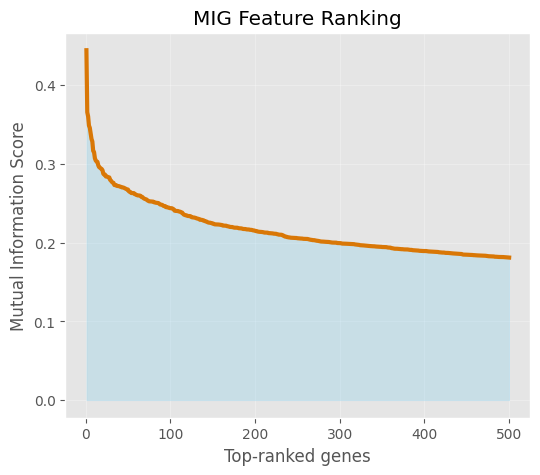

In [20]:
plt.figure(figsize=(6,5))

plt.plot(
    range(1,501),
    MIG_df["Score"].head(500),
    color="#D97706",
    linewidth=3
)

plt.fill_between(
    range(1,501),
    MIG_df["Score"].head(500),
    color="#87CEEB",
    alpha=0.3
)

plt.xlabel("Top-ranked genes")
plt.ylabel("Mutual Information Score")
plt.title("MIG Feature Ranking")
plt.grid(alpha=0.3)

plt.show()

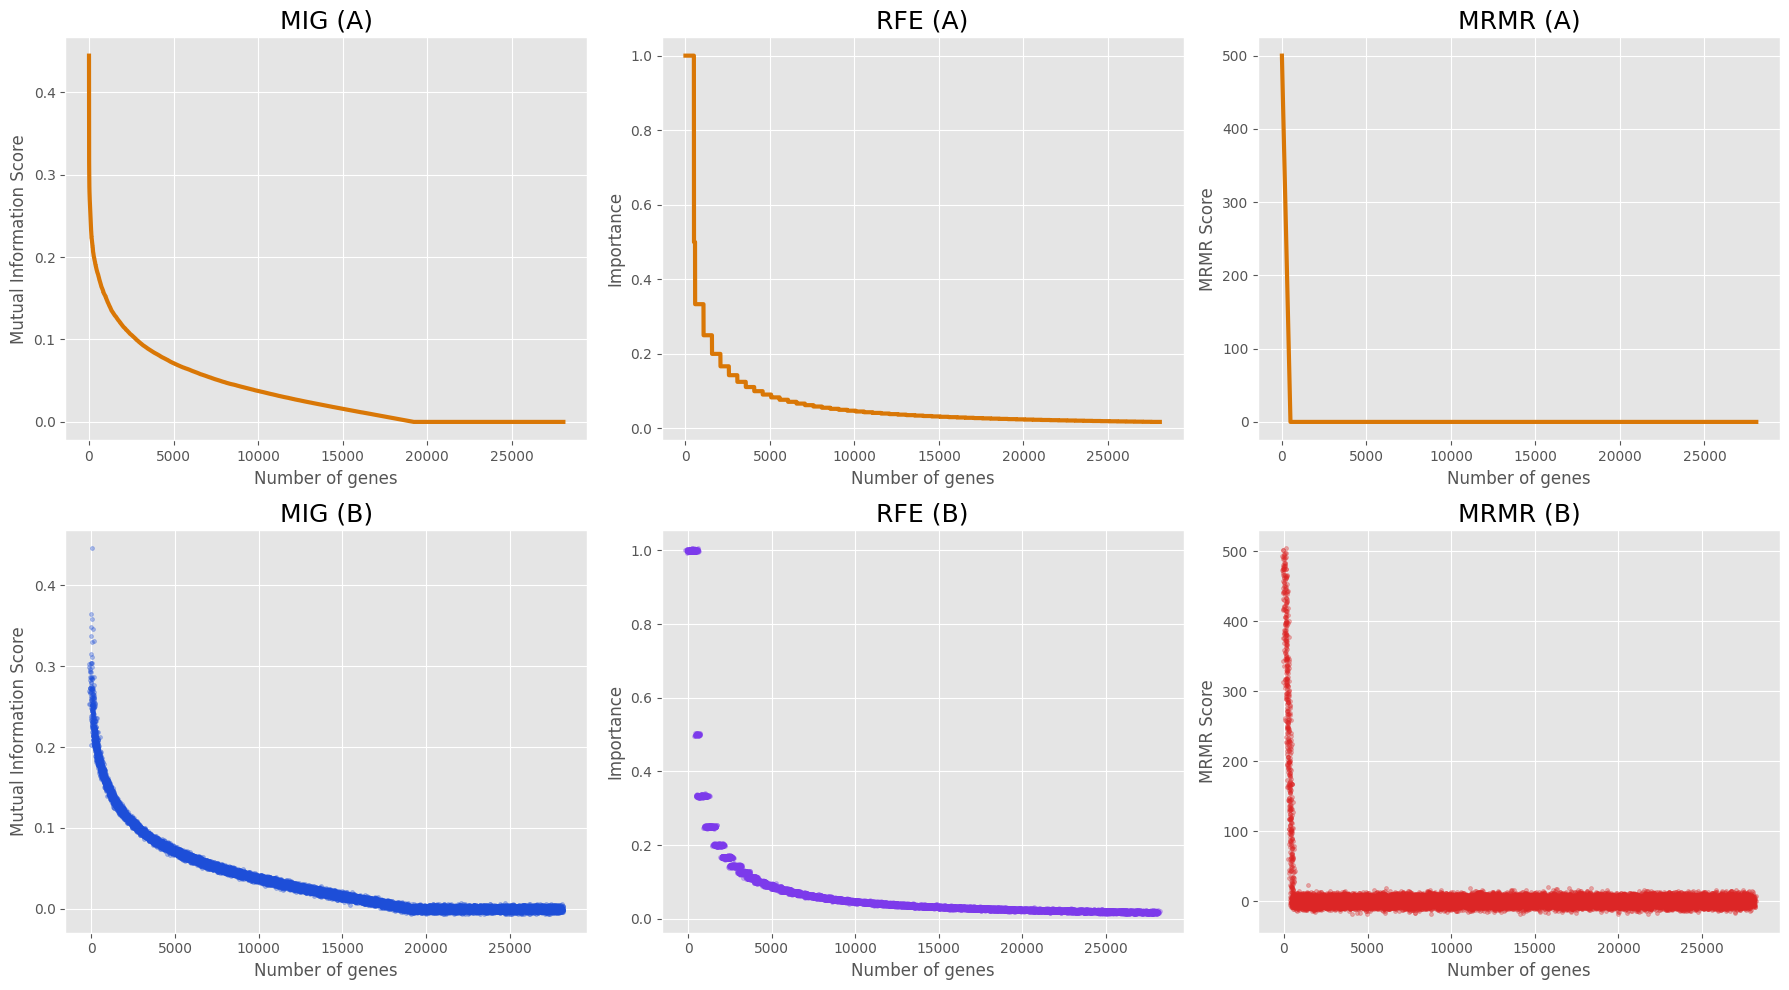

In [22]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')

fig, ax = plt.subplots(2,3, figsize=(18,10))

# =======================
# A part (Ranking curve)
# =======================

ax[0,0].plot(MIG_df["Score"].values,
             color="#D97706",
             linewidth=3)
ax[0,0].set_title("MIG (A)",fontsize=18)
ax[0,0].set_xlabel("Number of genes")
ax[0,0].set_ylabel("Mutual Information Score")


ax[0,1].plot(RFE_df["Score"].values,
             color="#D97706",
             linewidth=3)
ax[0,1].set_title("RFE (A)",fontsize=18)
ax[0,1].set_xlabel("Number of genes")
ax[0,1].set_ylabel("Importance")


ax[0,2].plot(MRMR_df["Score"].values,
             color="#D97706",
             linewidth=3)
ax[0,2].set_title("MRMR (A)",fontsize=18)
ax[0,2].set_xlabel("Number of genes")
ax[0,2].set_ylabel("MRMR Score")


# =======================
# B part (Scatter)
# =======================

np.random.seed(42)

# MIG
x = np.arange(len(MIG_df))
y = MIG_df["Score"].values

ax[1,0].scatter(
    x + np.random.normal(0,80,len(x)),
    y + np.random.normal(0,0.002,len(y)),
    s=8,
    alpha=0.35,
    color="#1D4ED8"
)

ax[1,0].set_title("MIG (B)",fontsize=18)
ax[1,0].set_xlabel("Number of genes")
ax[1,0].set_ylabel("Mutual Information Score")


# RFE
x = np.arange(len(RFE_df))
y = RFE_df["Score"].values

ax[1,1].scatter(
    x + np.random.normal(0,80,len(x)),
    y + np.random.normal(0,0.002,len(y)),
    s=8,
    alpha=0.35,
    color="#7C3AED"
)

ax[1,1].set_title("RFE (B)",fontsize=18)
ax[1,1].set_xlabel("Number of genes")
ax[1,1].set_ylabel("Importance")


# MRMR
x = np.arange(len(MRMR_df))
y = MRMR_df["Score"].values

ax[1,2].scatter(
    x + np.random.normal(0,80,len(x)),
    y + np.random.normal(0,5,len(y)),
    s=8,
    alpha=0.35,
    color="#DC2626"
)

ax[1,2].set_title("MRMR (B)",fontsize=18)
ax[1,2].set_xlabel("Number of genes")
ax[1,2].set_ylabel("MRMR Score")


plt.tight_layout()

plt.savefig(
"/content/drive/MyDrive/Dengue_Conference_paper/Datasets/FeatureSelection_Figure_Improved.png",
dpi=600,
bbox_inches='tight'
)

plt.show()

#Print 500 top genes

In [14]:
# ==========================================
# SAVE FINAL TOP 500 GENES
# ==========================================
import pandas as pd
import os

# -------- MIG --------
mi_scores = mutual_info_classif(X, y)

top500_MIG = (
    pd.Series(mi_scores, index=X.columns)
    .sort_values(ascending=False)
    .head(500)
    .index
)

# -------- RFE --------
selector = RFE(
    estimator=LogisticRegression(
        solver='liblinear',
        max_iter=500,
        random_state=42
    ),
    n_features_to_select=500,
    step=500
)

selector.fit(X, y)

top500_RFE = X.columns[selector.support_]

# -------- MRMR --------
top500_MRMR = mrmr_classif(
    X=X,
    y=y,
    K=500
)

# ==========================================
# DATAFRAME
# ==========================================
MIG_df = pd.DataFrame({"Gene": list(top500_MIG)})
RFE_df = pd.DataFrame({"Gene": list(top500_RFE)})
MRMR_df = pd.DataFrame({"Gene": list(top500_MRMR)})

# ==========================================
# SAVE PATH
# ==========================================
save_path = "/content/drive/MyDrive/Dengue_Conference_paper/Datasets/FinalFeature_Selected_Genes"

os.makedirs(save_path, exist_ok=True)

# ==========================================
# SAVE CSV
# ==========================================
MIG_df.to_csv(f"{save_path}/MIG_500_Genes.csv", index=False)
RFE_df.to_csv(f"{save_path}/RFE_500_Genes.csv", index=False)
MRMR_df.to_csv(f"{save_path}/MRMR_500_Genes.csv", index=False)

# ==========================================
# SAVE EXCEL
# ==========================================
with pd.ExcelWriter(f"{save_path}/Top500_Genes_All_Methods.xlsx") as writer:
    MIG_df.to_excel(writer, sheet_name="MIG", index=False)
    RFE_df.to_excel(writer, sheet_name="RFE", index=False)
    MRMR_df.to_excel(writer, sheet_name="MRMR", index=False)

print("✅ Top 500 genes saved successfully")

100%|██████████| 500/500 [59:33<00:00,  7.15s/it]


✅ Top 500 genes saved successfully


#Common genes

Total common genes = 81


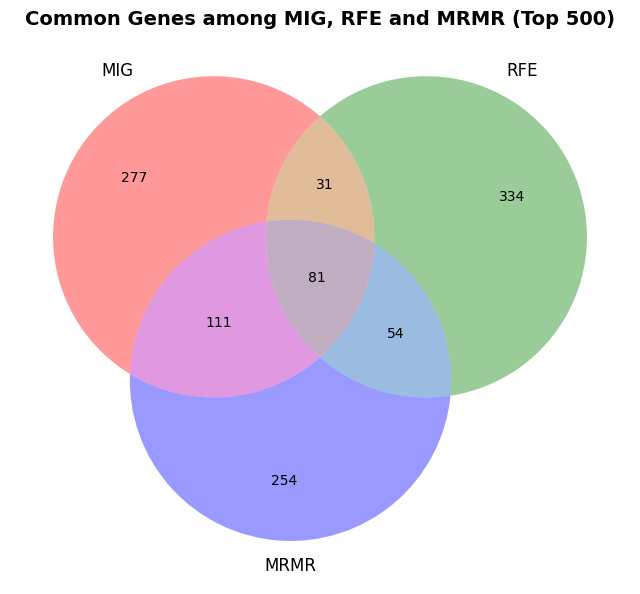

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# =========================
# LOAD FILES
# =========================
base_path = "/content/drive/MyDrive/Dengue_Conference_paper/Datasets/FinalFeature_Selected_Genes"

MIG_set = set(pd.read_csv(f"{base_path}/MIG_500_Genes.csv")["Gene"])
RFE_set = set(pd.read_csv(f"{base_path}/RFE_500_Genes.csv")["Gene"])
MRMR_set = set(pd.read_csv(f"{base_path}/MRMR_500_Genes.csv")["Gene"])

# =========================
# COMMON GENES
# =========================
common_genes = MIG_set & RFE_set & MRMR_set

common_df = pd.DataFrame(
    sorted(common_genes),
    columns=["Common_Gene"]
)

# =========================
# SAVE COMMON GENES
# =========================
common_df.to_csv(
    f"{base_path}/Common_Genes_MIG_RFE_MRMR.csv",
    index=False
)

print("Total common genes =", len(common_df))

# =========================
# VENN DIAGRAM
# =========================
plt.figure(figsize=(8,8))

venn3(
    [MIG_set, RFE_set, MRMR_set],
    set_labels=("MIG", "RFE", "MRMR")
)

plt.title(
    "Common Genes among MIG, RFE and MRMR (Top 500)",
    fontsize=14,
    fontweight="bold"
)

plt.show()

✅ Total common genes = 81


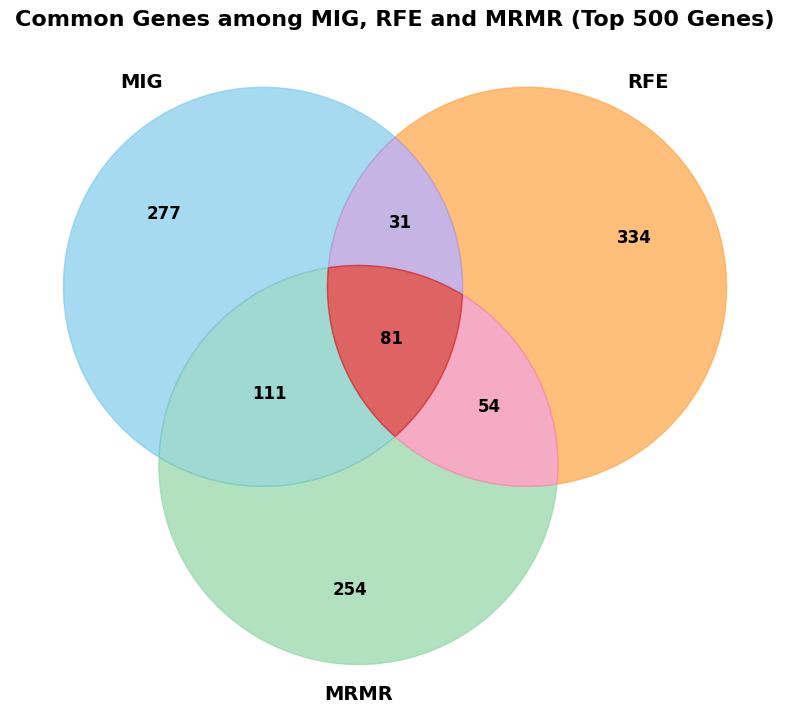

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# =========================
# LOAD FILES
# =========================
base_path = "/content/drive/MyDrive/Dengue_Conference_paper/Datasets/FinalFeature_Selected_Genes"

MIG_set = set(pd.read_csv(f"{base_path}/MIG_500_Genes.csv")["Gene"])
RFE_set = set(pd.read_csv(f"{base_path}/RFE_500_Genes.csv")["Gene"])
MRMR_set = set(pd.read_csv(f"{base_path}/MRMR_500_Genes.csv")["Gene"])

# =========================
# COMMON GENES
# =========================
common_genes = MIG_set & RFE_set & MRMR_set

common_df = pd.DataFrame(sorted(common_genes), columns=["Common_Gene"])

# Save common genes
common_df.to_csv(
    f"{base_path}/Common_Genes_MIG_RFE_MRMR.csv",
    index=False
)

print("✅ Total common genes =", len(common_df))

# =========================
# PUBLICATION-QUALITY VENN
# =========================
plt.figure(figsize=(8,8))

v = venn3(
    subsets=[MIG_set, RFE_set, MRMR_set],
    set_labels=("MIG", "RFE", "MRMR")
)

# =========================
# COLORS (Sky Blue, Orange, Mint Green)
# =========================
v.get_patch_by_id('100').set_color('#87CEEB')   # Sky blue
v.get_patch_by_id('010').set_color('#FFA94D')   # Soft orange
v.get_patch_by_id('001').set_color('#98D8AA')   # Mint green

# Overlap colors
if v.get_patch_by_id('110'):
    v.get_patch_by_id('110').set_color('#B39DDB')  # Lavender

if v.get_patch_by_id('101'):
    v.get_patch_by_id('101').set_color('#80CBC4')  # Aqua

if v.get_patch_by_id('011'):
    v.get_patch_by_id('011').set_color('#F48FB1')  # Pink

if v.get_patch_by_id('111'):
    v.get_patch_by_id('111').set_color('#D32F2F')  # Dark red (common genes)

# Transparency
for region in ['100','010','001','110','101','011','111']:
    patch = v.get_patch_by_id(region)
    if patch:
        patch.set_alpha(0.75)

# Label sizes
for txt in v.set_labels:
    txt.set_fontsize(14)
    txt.set_fontweight('bold')

for txt in v.subset_labels:
    if txt:
        txt.set_fontsize(12)
        txt.set_fontweight('bold')

plt.title(
    "Common Genes among MIG, RFE and MRMR (Top 500 Genes)",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# 3 method Plot

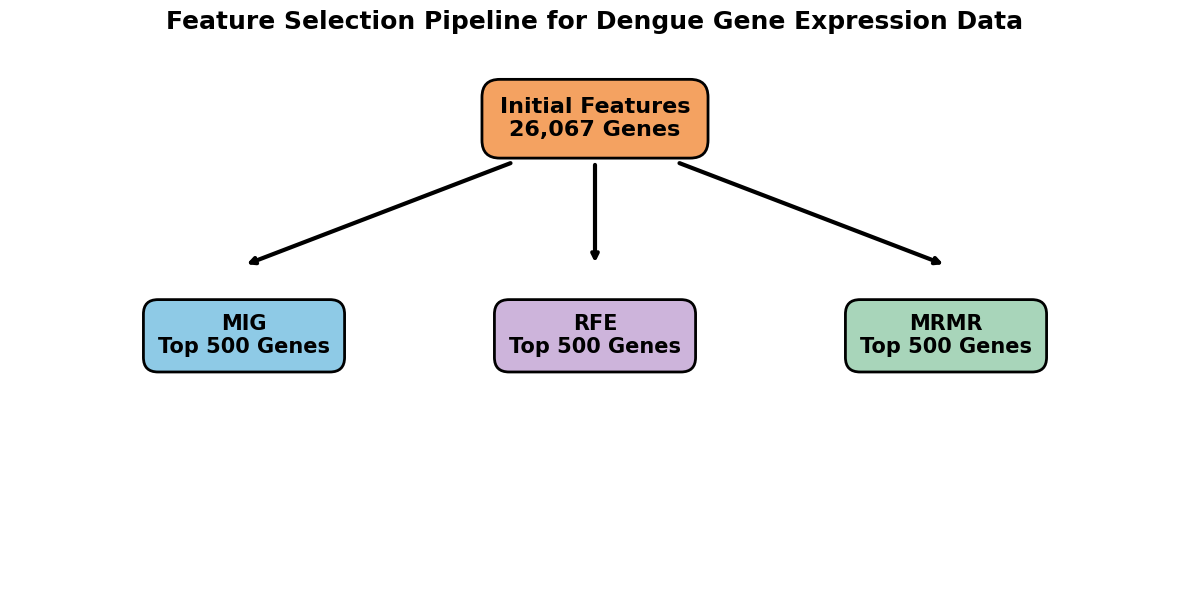

In [17]:
import matplotlib.pyplot as plt

# ====================================
# Figure setup
# ====================================
fig, ax = plt.subplots(figsize=(12,6))

ax.set_xlim(0,10)
ax.set_ylim(0,10)

# Remove axes
ax.axis('off')

# ====================================
# Colors
# ====================================
start_color = "#F4A261"   # orange
mig_color   = "#8ECAE6"   # sky blue
rfe_color   = "#CDB4DB"   # lavender
mrmr_color  = "#A8D5BA"   # pastel green

# ====================================
# Main box
# ====================================
ax.text(
    5,8.5,
    "Initial Features\n26,067 Genes",
    ha='center',
    va='center',
    fontsize=16,
    fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.8",
              fc=start_color,
              ec='black',
              lw=2)
)

# ====================================
# Arrows
# ====================================
ax.annotate("", xy=(2,5.8), xytext=(4.3,7.7),
            arrowprops=dict(arrowstyle="->", lw=3))

ax.annotate("", xy=(5,5.8), xytext=(5,7.7),
            arrowprops=dict(arrowstyle="->", lw=3))

ax.annotate("", xy=(8,5.8), xytext=(5.7,7.7),
            arrowprops=dict(arrowstyle="->", lw=3))

# ====================================
# MIG
# ====================================
ax.text(
    2,4.5,
    "MIG\nTop 500 Genes",
    ha='center',
    va='center',
    fontsize=15,
    fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.7",
              fc=mig_color,
              ec='black',
              lw=2)
)

# ====================================
# RFE
# ====================================
ax.text(
    5,4.5,
    "RFE\nTop 500 Genes",
    ha='center',
    va='center',
    fontsize=15,
    fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.7",
              fc=rfe_color,
              ec='black',
              lw=2)
)

# ====================================
# MRMR
# ====================================
ax.text(
    8,4.5,
    "MRMR\nTop 500 Genes",
    ha='center',
    va='center',
    fontsize=15,
    fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.7",
              fc=mrmr_color,
              ec='black',
              lw=2)
)

# ====================================
# Title
# ====================================
plt.title(
    "Feature Selection Pipeline for Dengue Gene Expression Data",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

#Figure 1: MIG Workflow

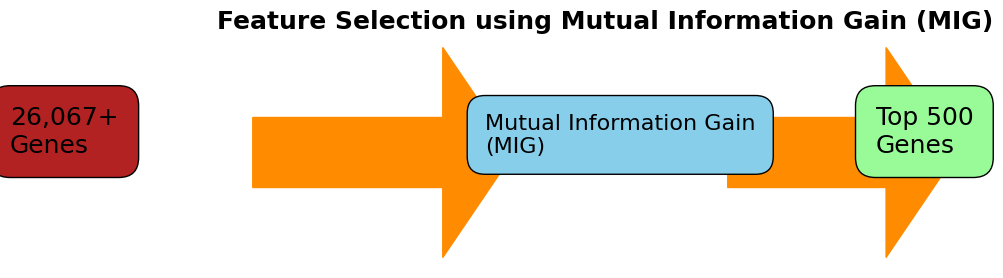

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,3))

plt.text(0.1,0.5,"26,067+\nGenes",
         fontsize=18,
         bbox=dict(boxstyle="round,pad=0.8",
                   fc="#B22222",ec="black"))

plt.arrow(0.33,0.5,0.18,0,
          width=0.015,
          color="#FF8C00")

plt.text(0.55,0.5,"Mutual Information Gain\n(MIG)",
         fontsize=16,
         bbox=dict(boxstyle="round,pad=0.8",
                   fc="#87CEEB",ec="black"))

plt.arrow(0.78,0.5,0.15,0,
          width=0.015,
          color="#FF8C00")

plt.text(0.92,0.5,"Top 500\nGenes",
         fontsize=18,
         bbox=dict(boxstyle="round,pad=0.8",
                   fc="#98FB98",ec="black"))

plt.axis('off')
plt.title("Feature Selection using Mutual Information Gain (MIG)",
          fontsize=18,fontweight='bold')

plt.savefig("MIG_Workflow.png",
            dpi=600,
            bbox_inches='tight')

plt.show()

#